CAM1H
  Crab Source Position in the camera local-frame coords
  - shifts: (-52.55320588166768, -56.199841769251)
  - angles: (np.float64(-14.510818374736035), np.float64(-15.470935671066176))
  - RA - DEC: CoordEquatorial(ra=83.6332015991211, dec=22.014499664306626)
  - CAM pointings: {'z': CoordEquatorial(ra=65.6737015953277, dec=35.6486362123488), 'x': CoordEquatorial(ra=257.33165649948, dec=53.7838910823791)}
  - Wanted CAM pointings: CoordEquatorial(ra=83.1078519664901, dec=21.540083357047777)



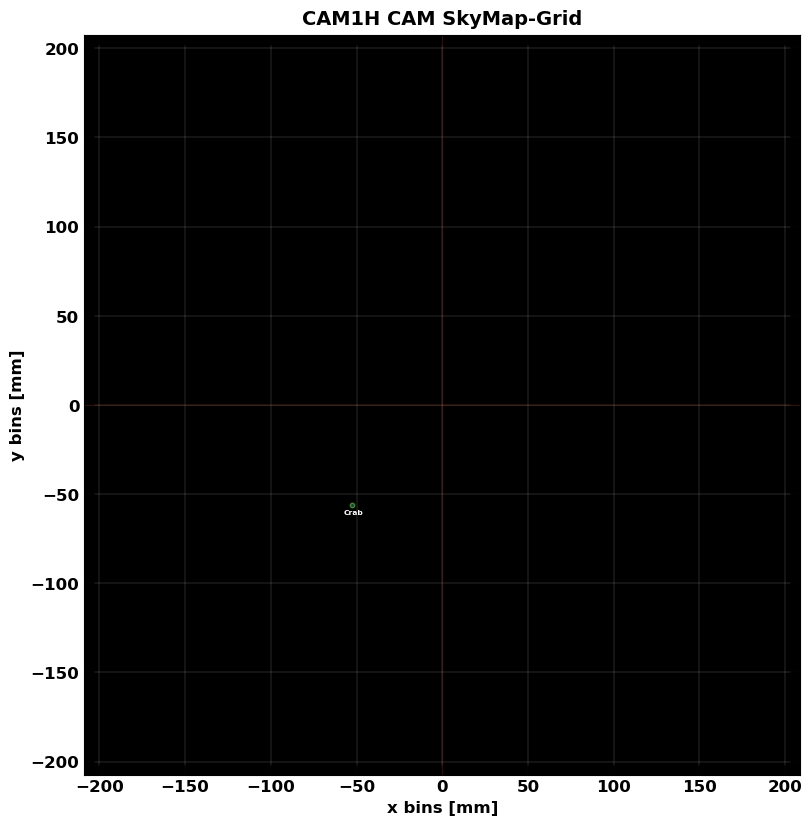

In [ ]:
from pathlib import Path

from bloodmoon.coords import equatorial2shift, shift2angle, shift2equatorial, angle2shift
from bloodmoon.mask import codedmask, count, decode

import darksun as ds
from darksun.types import LogEntry
from darksun.show import skyfield_map


# setup mask and data
base_path = '/home/edoardo/Datadisk/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations'
skyfield = 'Crab/PointingTests'
mask_FITS = 'wfm_mask_NTHT_20250725.fits'
data_FITS = 'test_camera_tilt'
filepath = f'{base_path}/{skyfield}/{data_FITS}'

UPX, UPY = 1, 1
wfm = codedmask(f'{base_path}/{mask_FITS}', UPX, UPY)

CrabRA = 83.6332015991211
CrabDEC = 22.0144996643066
cameras = tuple(p.name for p in Path(filepath).glob('*cam1h*') if p.is_dir())


for camID in cameras:
    sdlA = ds.get_data(f'{filepath}/{camID}/{data_FITS}_{camID}_detected.fits')
    detector, _ = count(wfm, sdlA.DLdata)
    sky = decode(wfm, detector)
    shiftx, shifty = equatorial2shift(sdlA, wfm, CrabRA, CrabDEC)
    thetax, thetay = tuple(map(lambda x: shift2angle(wfm, x), (shiftx, shifty)))
    print(
        f'{camID.upper()}\n'
        f'  Crab Source Position in the camera local-frame coords\n'
        f'  - shifts: {shiftx, shifty}\n'
        f'  - angles: {thetax, thetay}\n'
        f'  - RA - DEC: {shift2equatorial(sdlA, wfm, shiftx, shifty)}\n'
        f'  - CAM pointings: {sdlA.pointings}\n'
        f'  - Wanted CAM pointings: {shift2equatorial(
            sdlA, wfm, angle2shift(wfm, -15.0), angle2shift(wfm, -15.0),
        )}\n'
    )

    # show source position in skymap
    params = (
        LogEntry('ID', '20A', ''), LogEntry('shift_x', 'D', 'mm'), LogEntry('shift_y', 'D', 'mm'),
    )
    source_log = ds.create_log(
        params=params,
        name=f'{camID} CAM'
    )
    source_log.update(tuple((p.entry, val) for p, val in zip(params, ('Crab', shiftx, shifty))))
    skyfield_map(
        log=source_log,
        camera=wfm,
    )

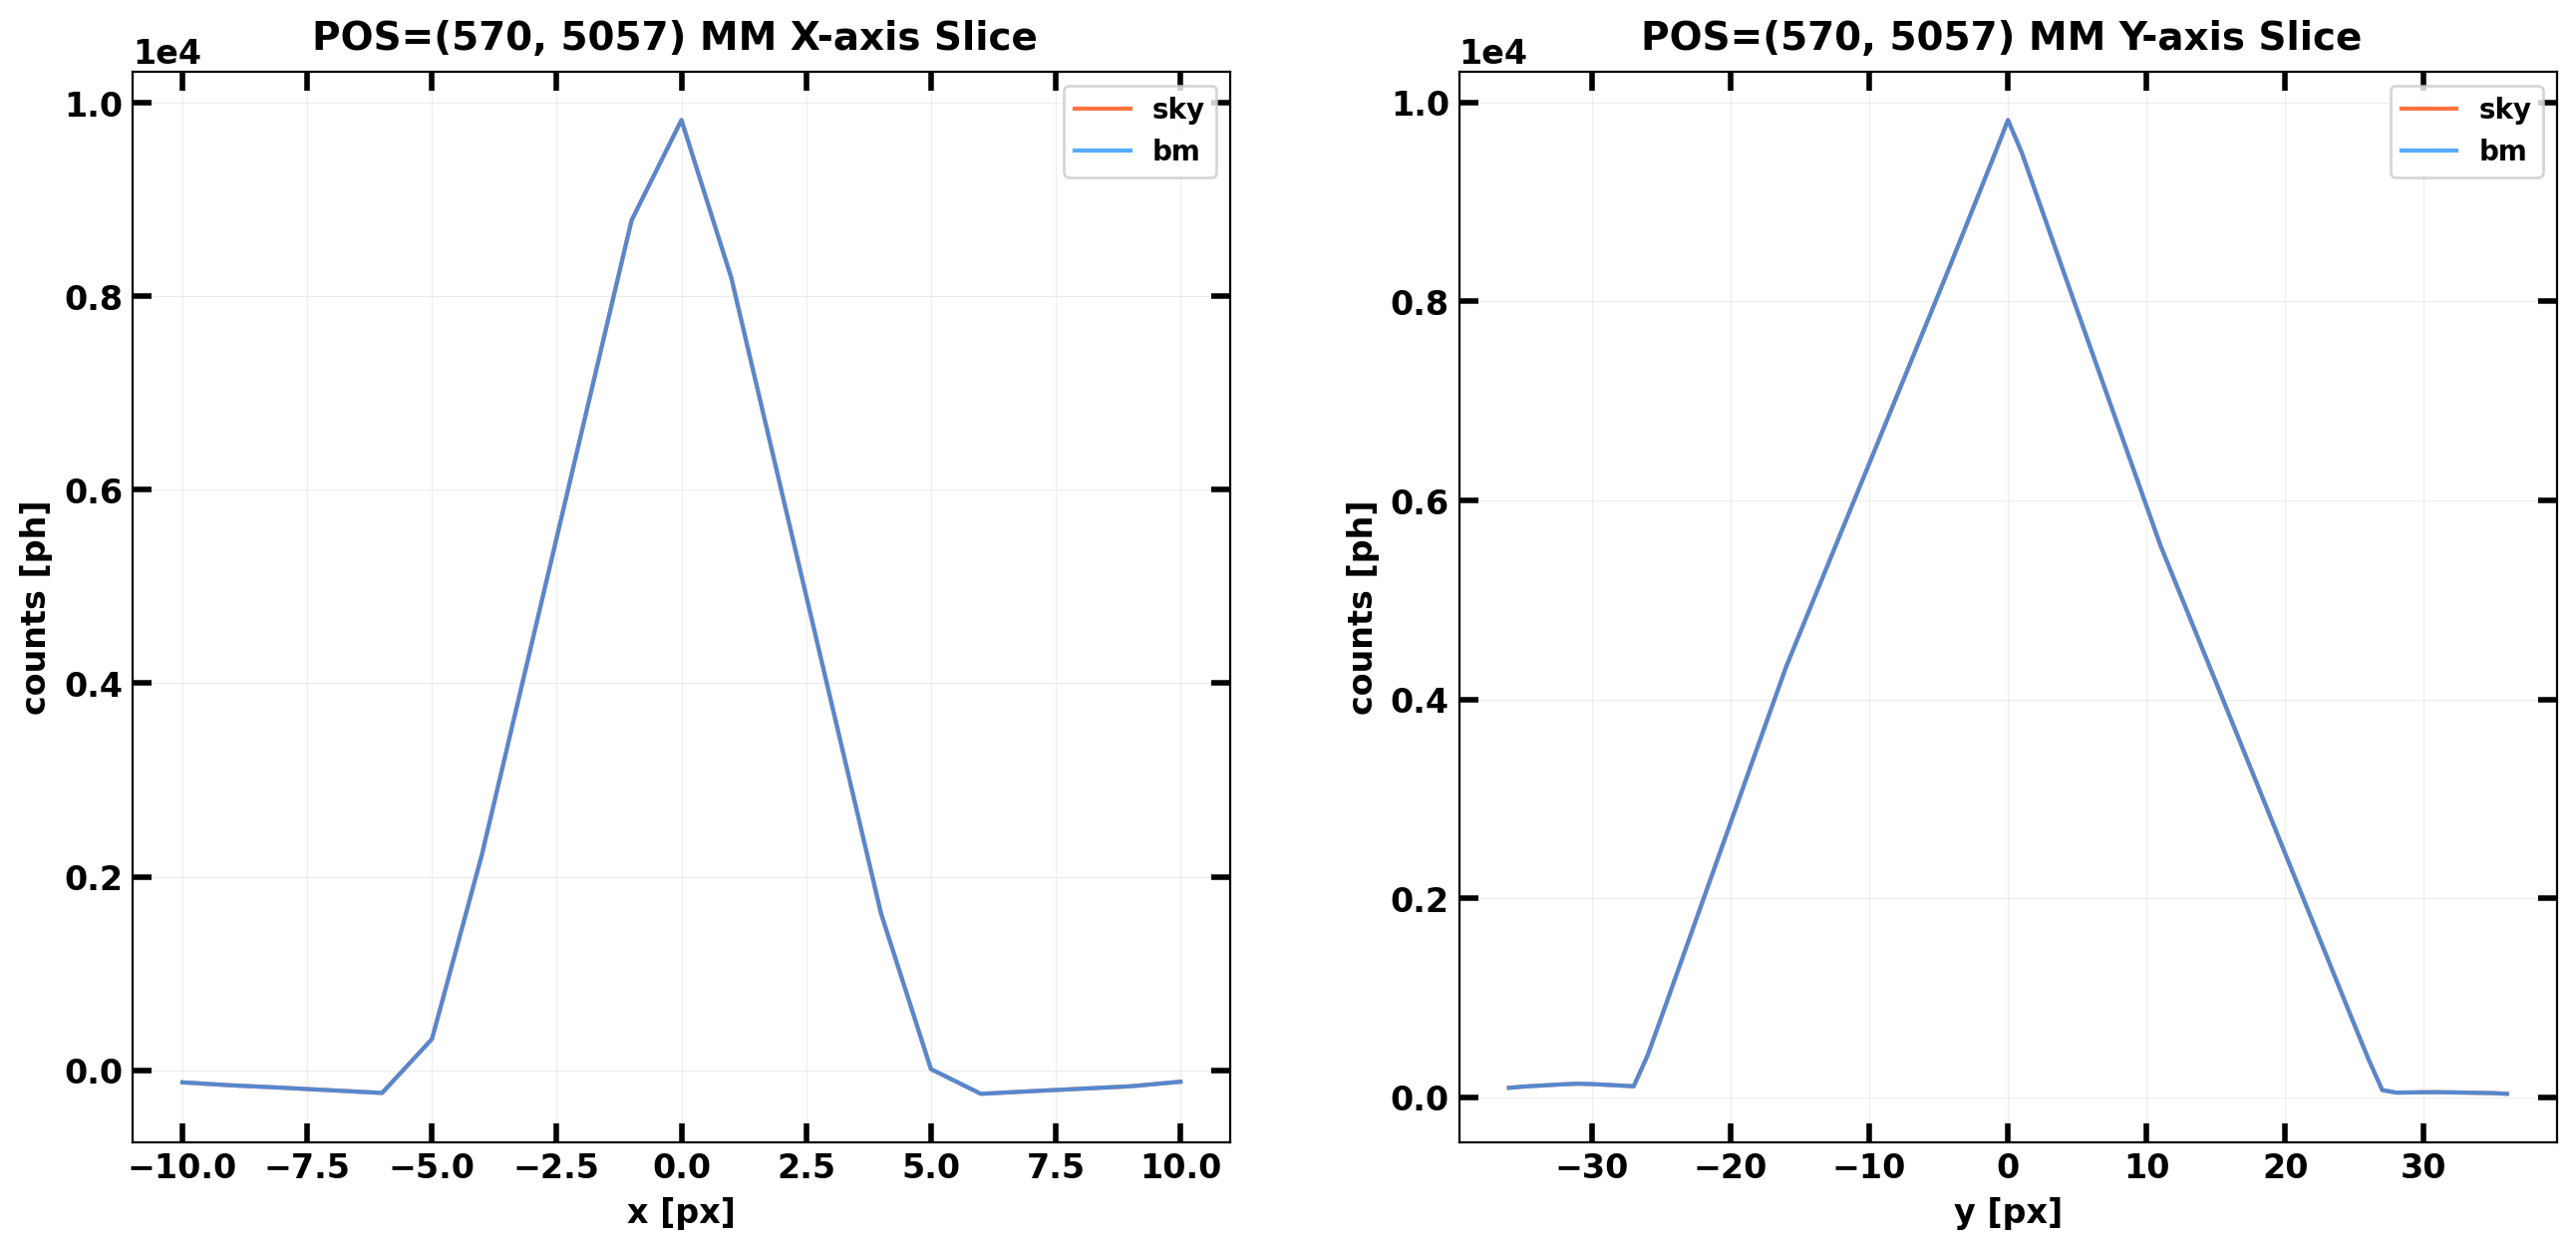

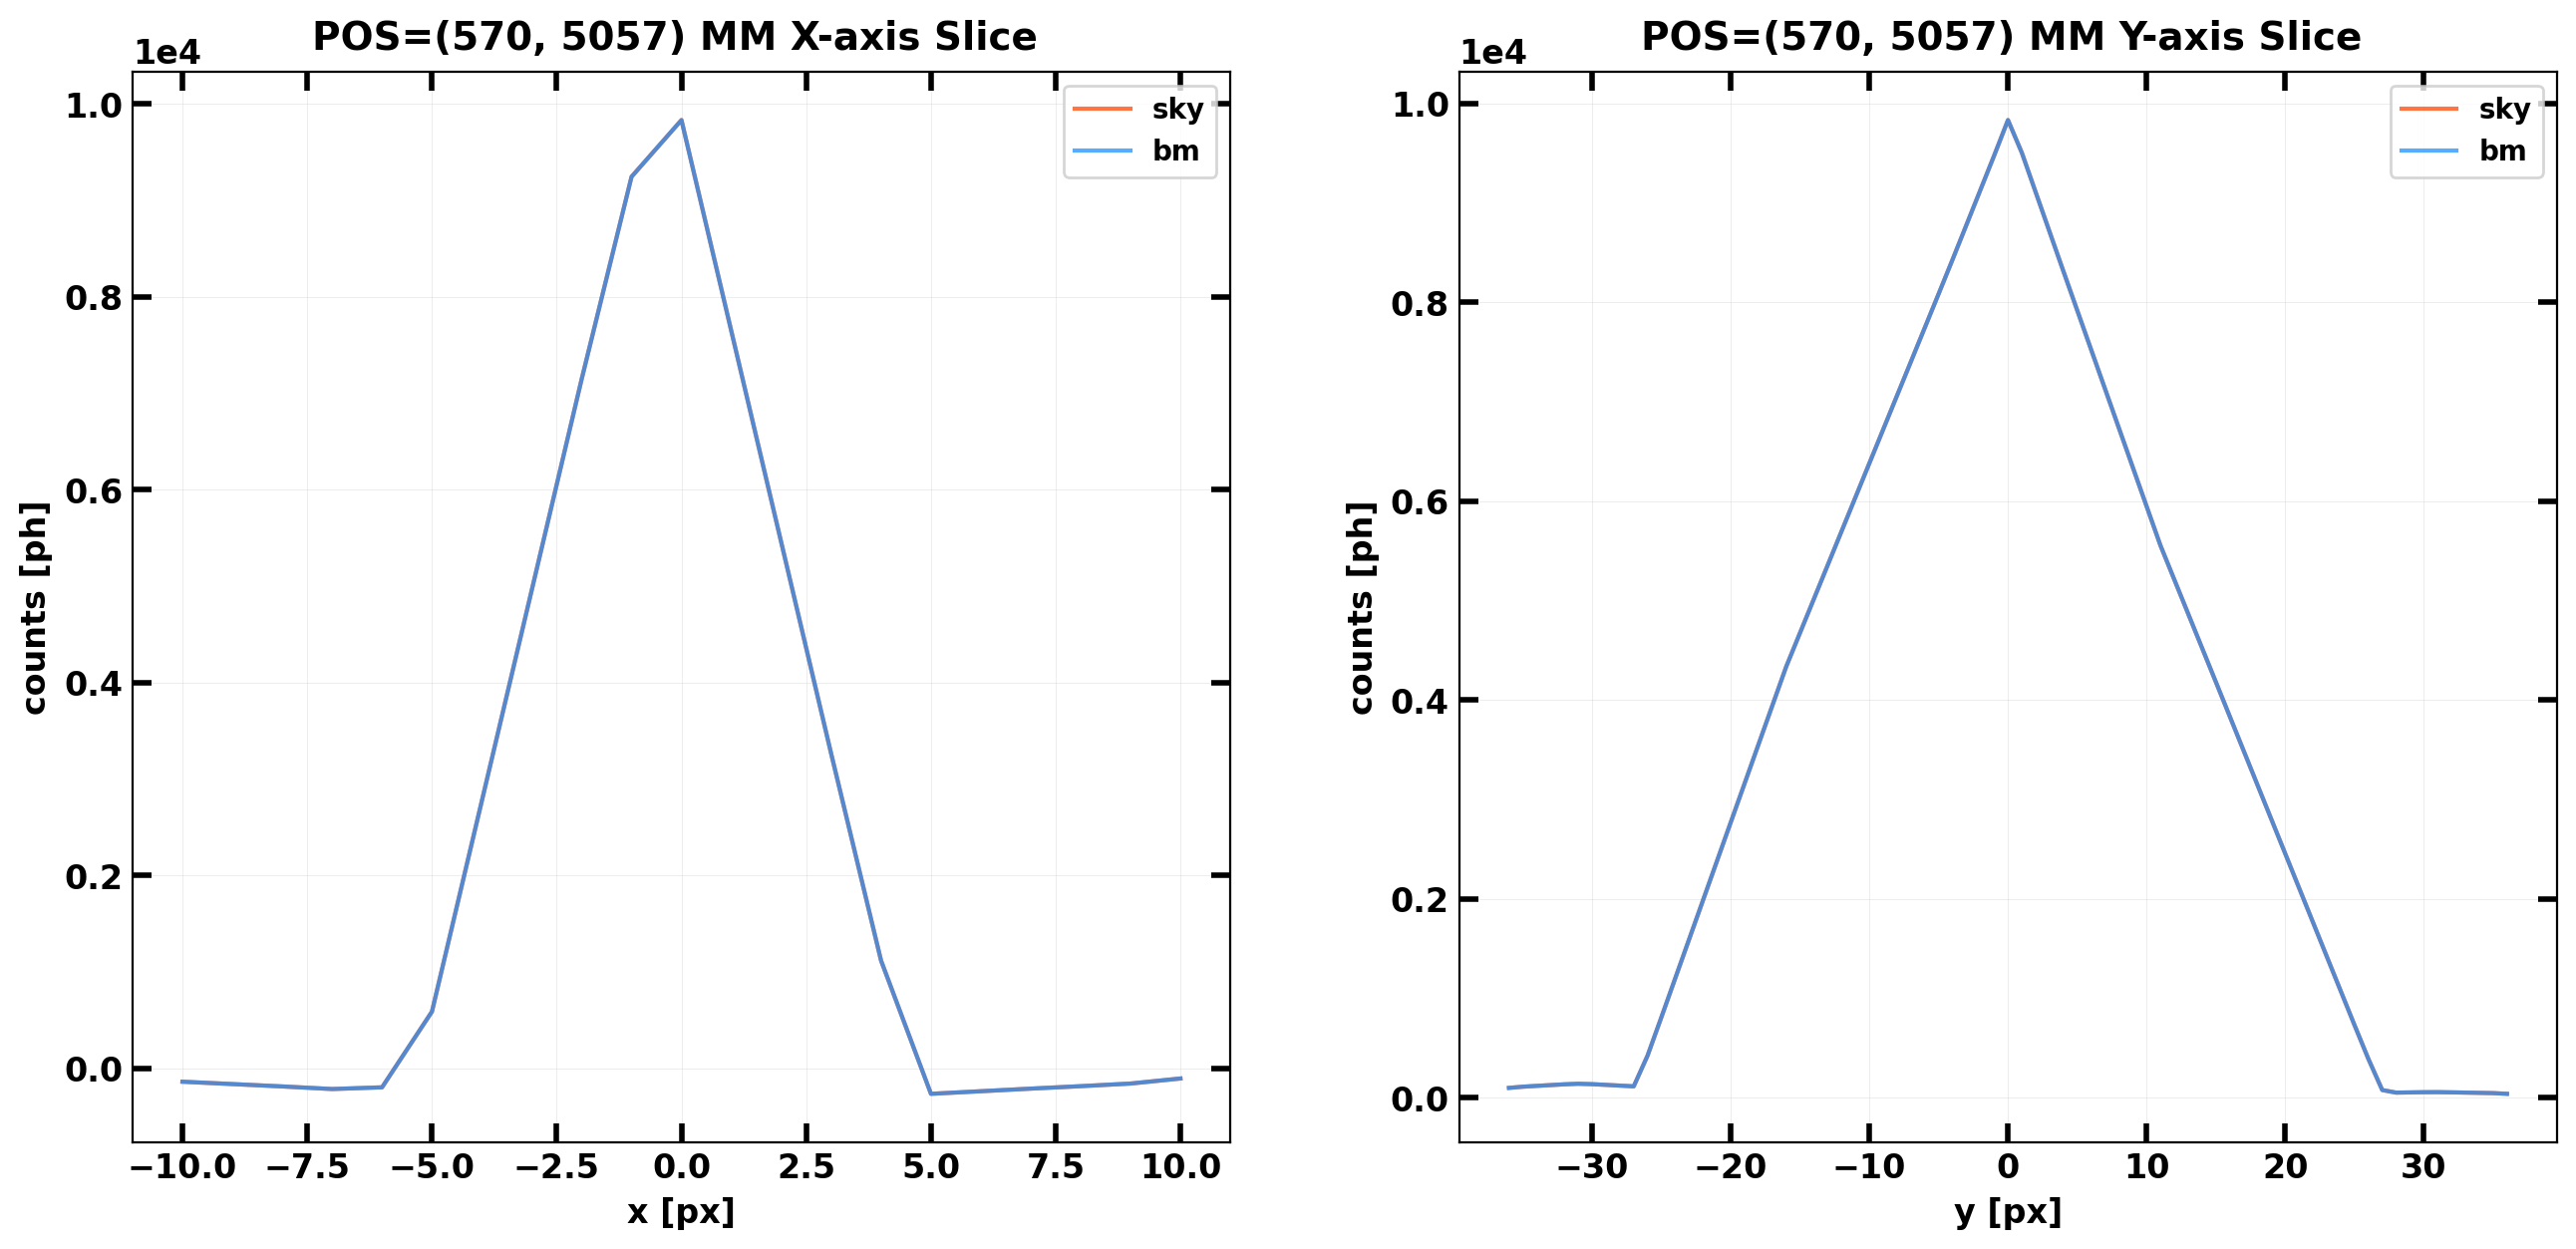

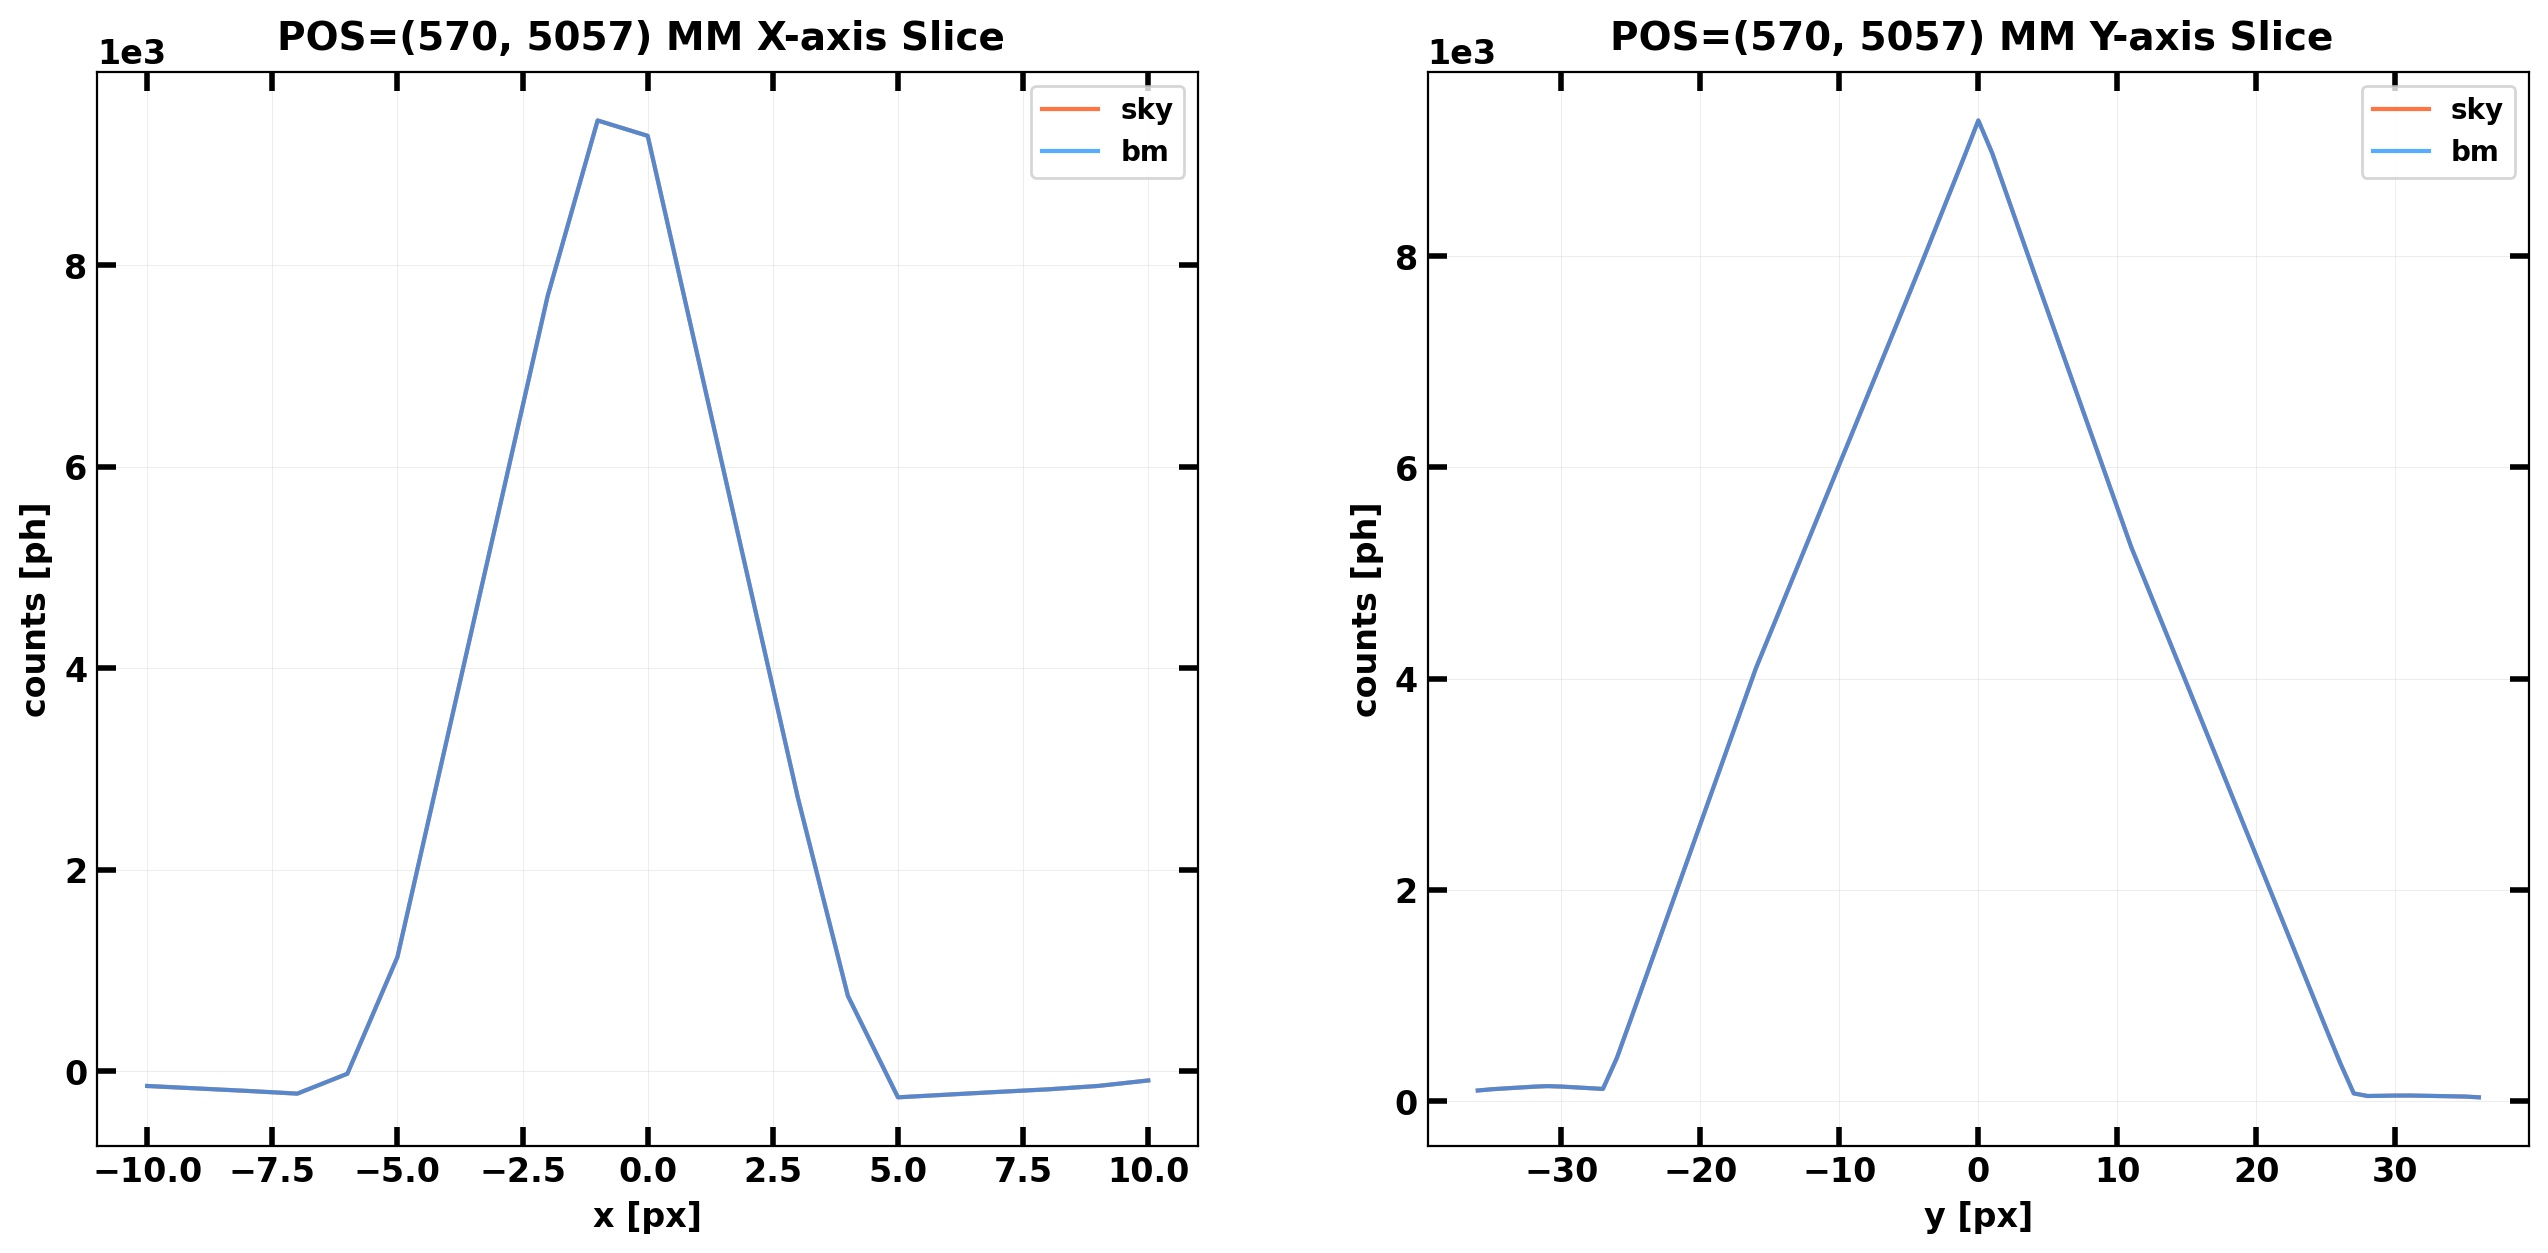

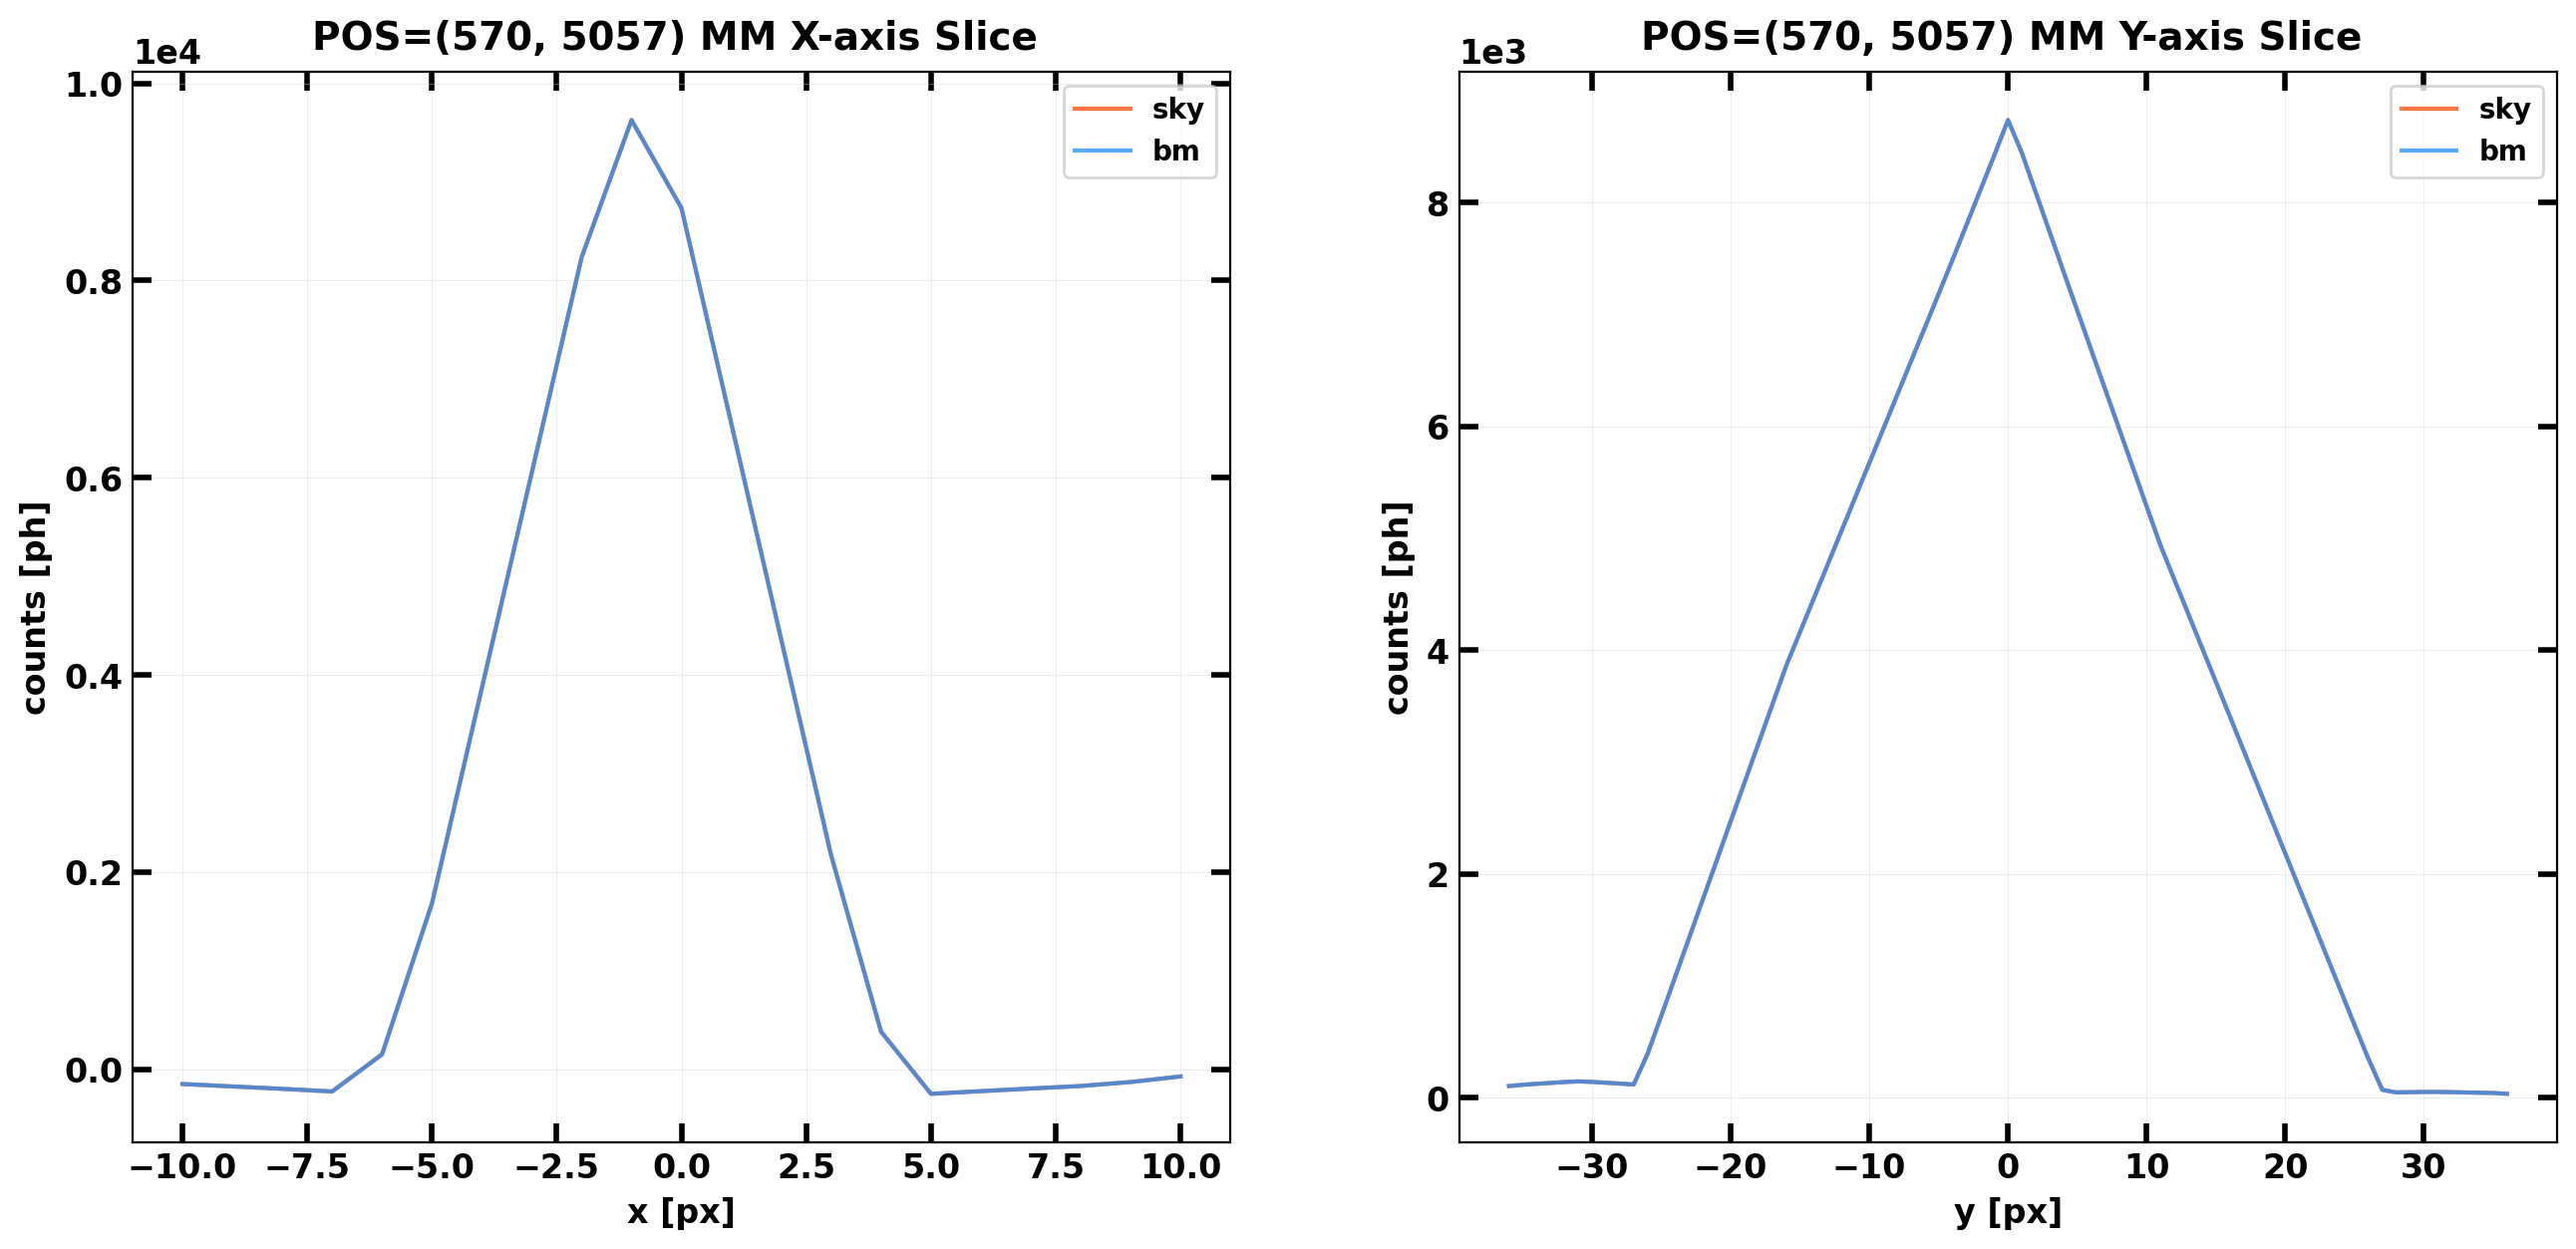

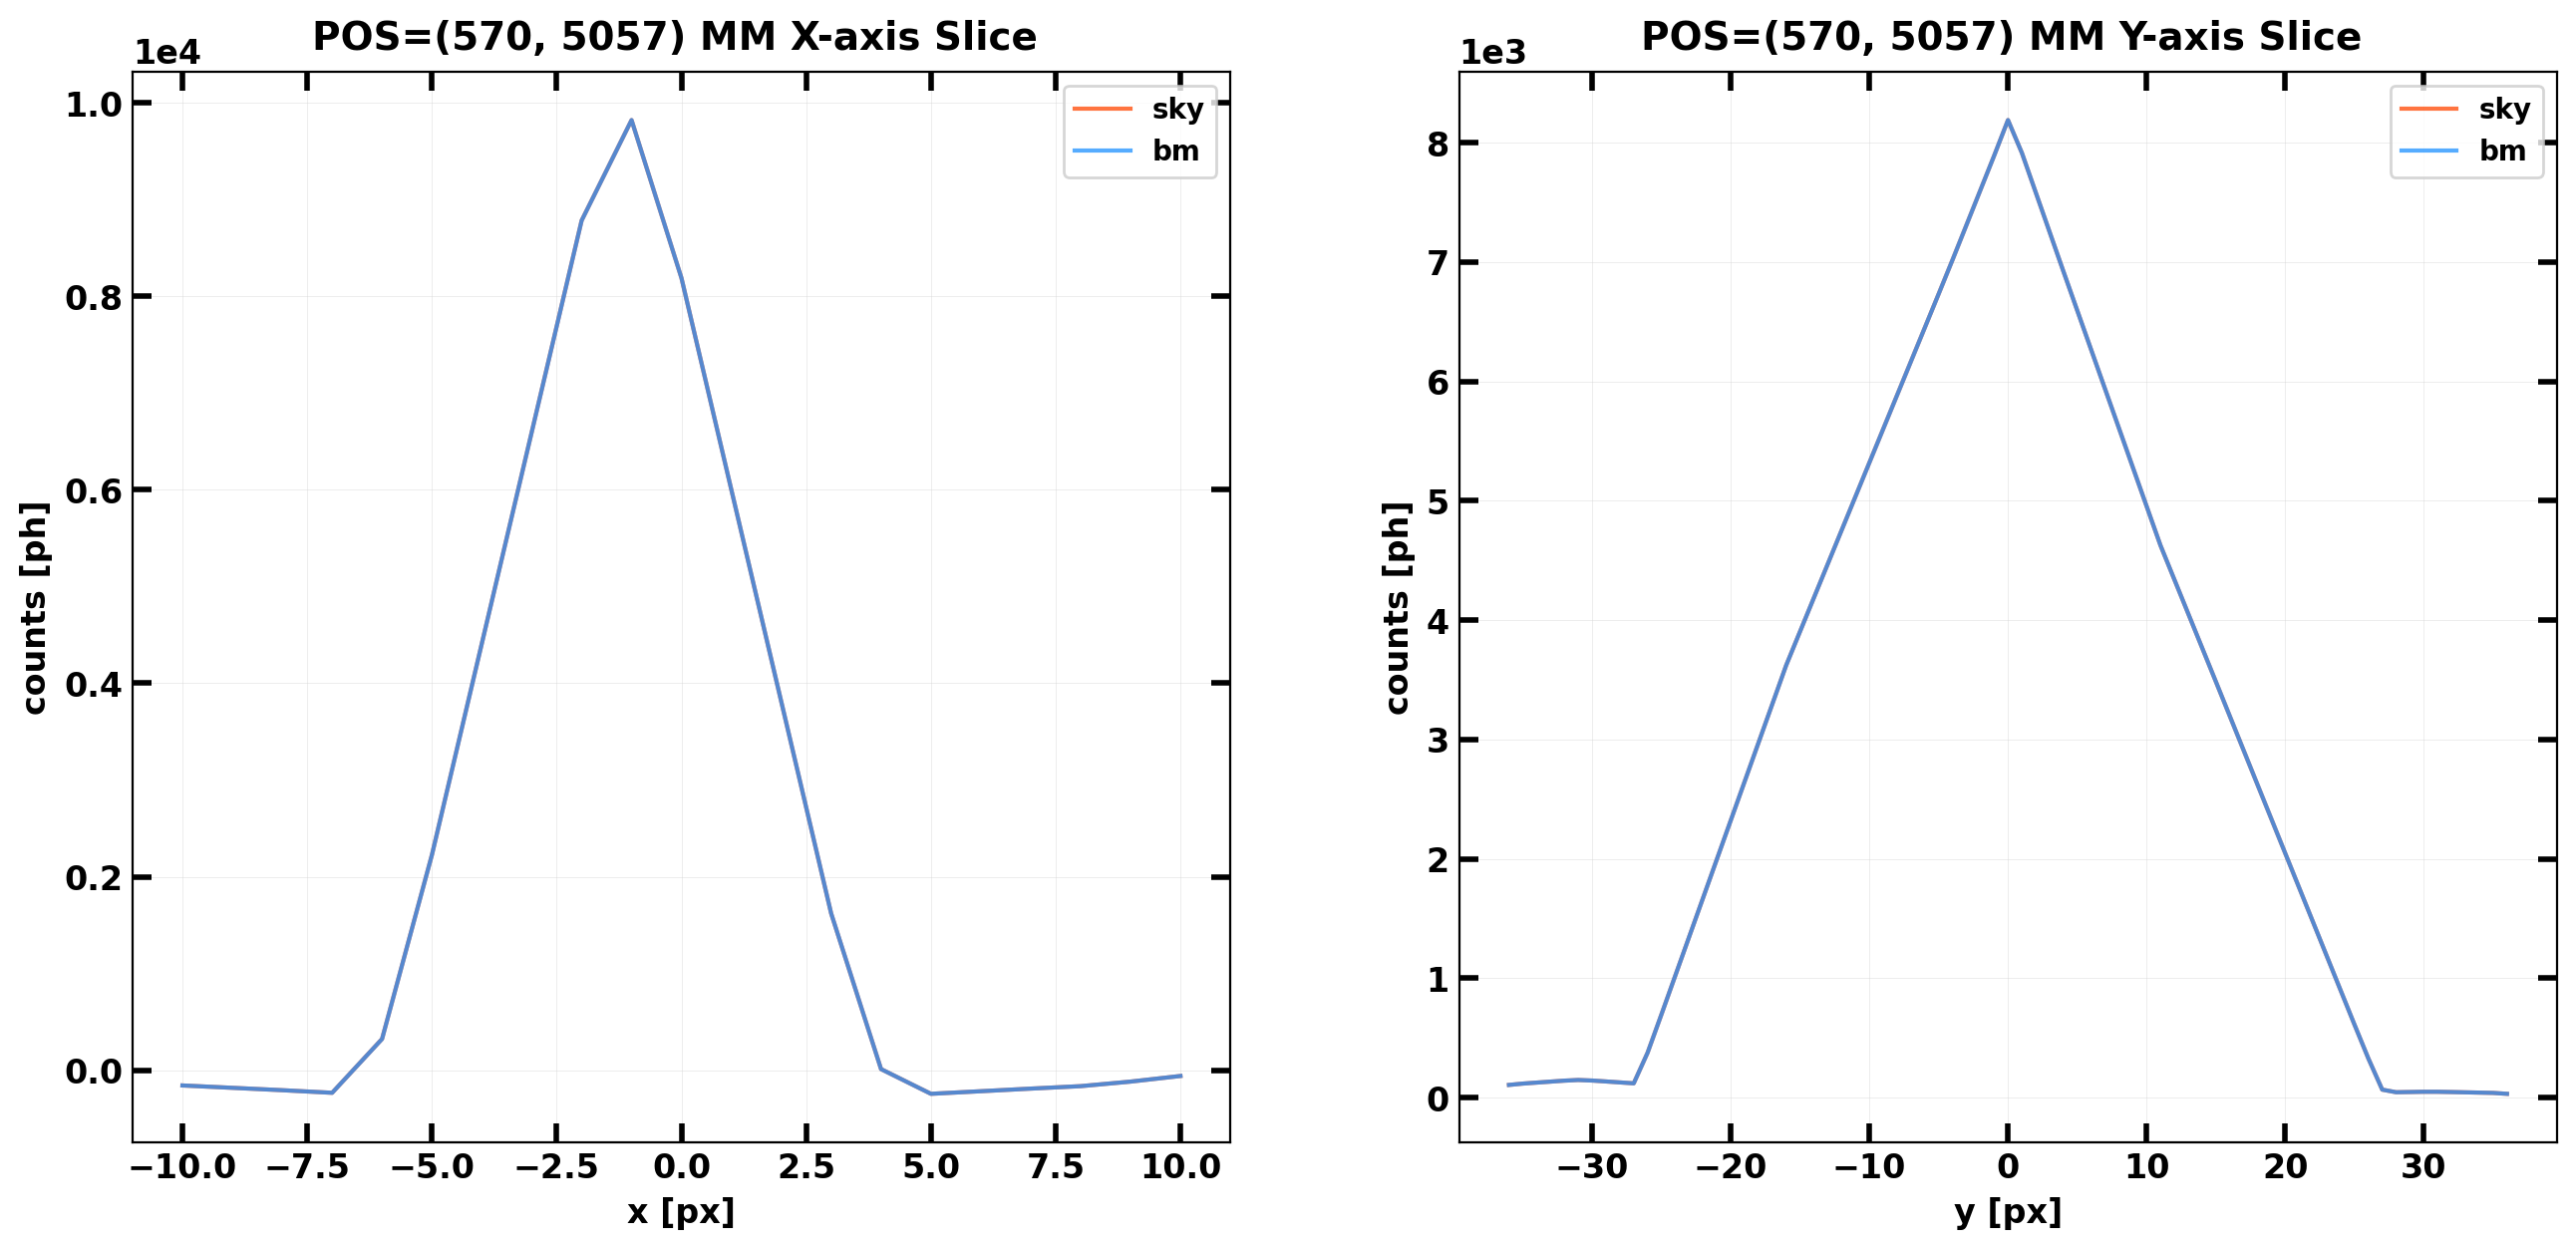

In [4]:
import numpy as np
from numpy.typing import NDArray

from bloodmoon.coords import shift2pos, angle2shift
from bloodmoon.mask import codedmask, decode
from bloodmoon.optim import model_shadowgram as bm_sg

import darksun as ds

from fract_shift2 import model_shadowgram


def sqrt_display(arr: NDArray, exp: int | float) -> NDArray:
    """Computes the root of the input array with the given exponent."""
    if exp > 1:
        raise ValueError('The exponent is supposed to be in the range [0, 1].')
    return np.pow(np.clip(arr, a_min=1e-5, a_max=None), exp)


UPX, UPY = 5, 1
mask_path = '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/wfm_mask_NTHT_20250725.fits'
#mask_path = '/mnt/d/PhD_AASS/Coding/Images_fits/wfm_mask_NTHT_20250725.fits'
wfm = codedmask(mask_path, UPX, UPY)
ASPECT = (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)


thetax, thetay = 12.202274809914625, 21.025135698738143
shiftx, shifty = map(
    lambda x: angle2shift(wfm, x),
    (thetax, thetay),
)

VIGNETTING = True
PSFY = False

pxdimy, pxdimx = (
    wfm.specs['mask_deltay'] / wfm.upscale_f.y,
    wfm.specs['mask_deltax'] / wfm.upscale_f.x,
)


for alpha in (0.0, 0.25, 0.5, 0.75, 1.0):

    detector = model_shadowgram(
        camera=wfm,
        shift_x=shiftx - alpha * pxdimx,
        shift_y=shifty,
        vignetting=VIGNETTING,
        psfy=PSFY,
    )
    bm_detector = bm_sg(
        camera=wfm,
        shift_x=shiftx - alpha * pxdimx,
        shift_y=shifty,
        vignetting=VIGNETTING,
        psfy=PSFY,
    )

    fluence = 1e4
    exp = 0.75
    sky = fluence * decode(wfm, detector)
    bm_sky = fluence * decode(wfm, bm_detector)

    i, j = shift2pos(wfm, shiftx, shifty)
    crp = (
        int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
        int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
    )
    #crp_sky = ds.crop(
    #    image=sqrt_display(sky, exp),
    #    pos=(i, j),
    #    crp=crp,
    #    strict=False,
    #)
    #F_UPY, F_UPX = 2, 5
    #
    #ds.image_plot(
    #    dmaps=(
    #        ds.map4image(
    #            img=detector,
    #            title=f'Detector (x, y)=({thetax}, {thetay}) deg',
    #            cbarlabel='counts',
    #            img_kwargs={
    #                'cmap': 'hot',
    #                'vmin': np.unique(detector)[1],
    #                'aspect': ASPECT,
    #            },
    #        ),
    #        ds.map4image(
    #            img=ds.upscale(crp_sky, F_UPY, F_UPX) * np.prod((F_UPY, F_UPX)),
    #            title=f'Source (x, y)=({thetax}, {thetay}) deg',
    #            cbarlabel='counts',
    #            img_kwargs={
    #                'cmap': 'plasma',
    #                'vmax': 0.75 * pow(fluence, exp),
    #                #'aspect': ASPECT,
    #            },
    #        ),
    #    ),
    #    ncols=2,
    #    #save_to=is_img(save_to, f'sky_{tx_}{ty_}_sameVignettingSign'),
    #)
    ds.slices_plot(
        sky=(sky, bm_sky),
        pos=(i, j),
        crp=crp,
        #source=f'(x, y)=({thetax}, {thetay}) deg',
        source=f'pos=({i}, {j}) mm',
        labels=('sky', 'bm')
        #save_to=is_img(save_to, f'skyslice_{tx_}{ty_}_sameVignettingSign'),
    )

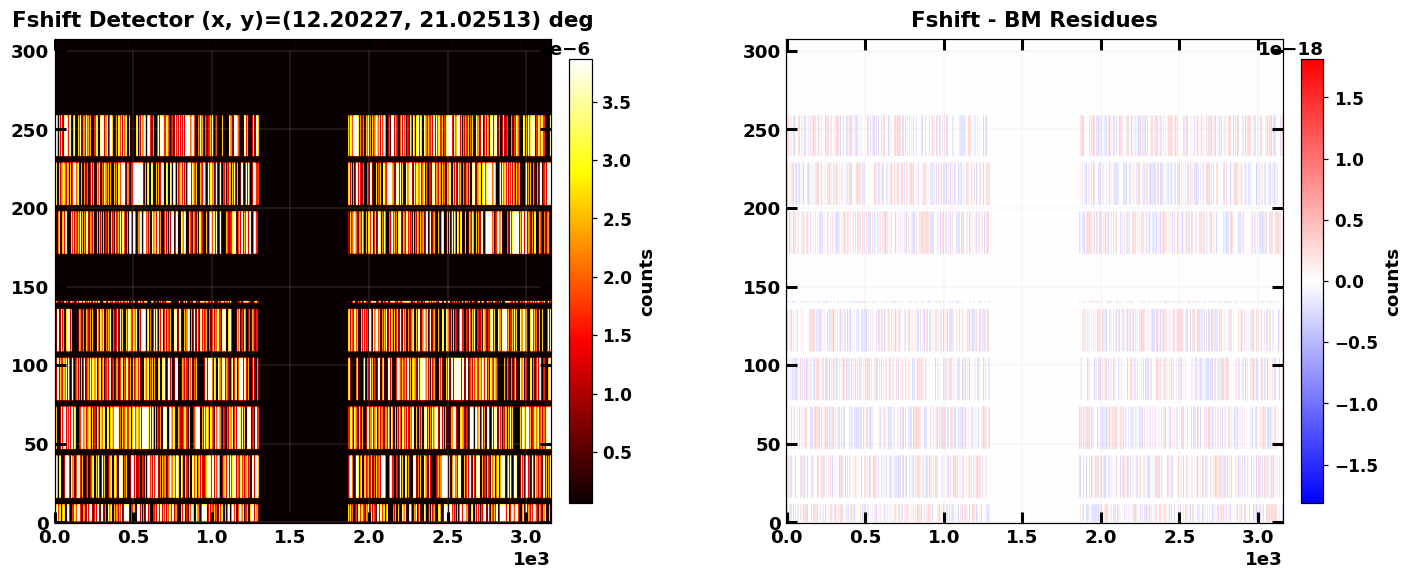

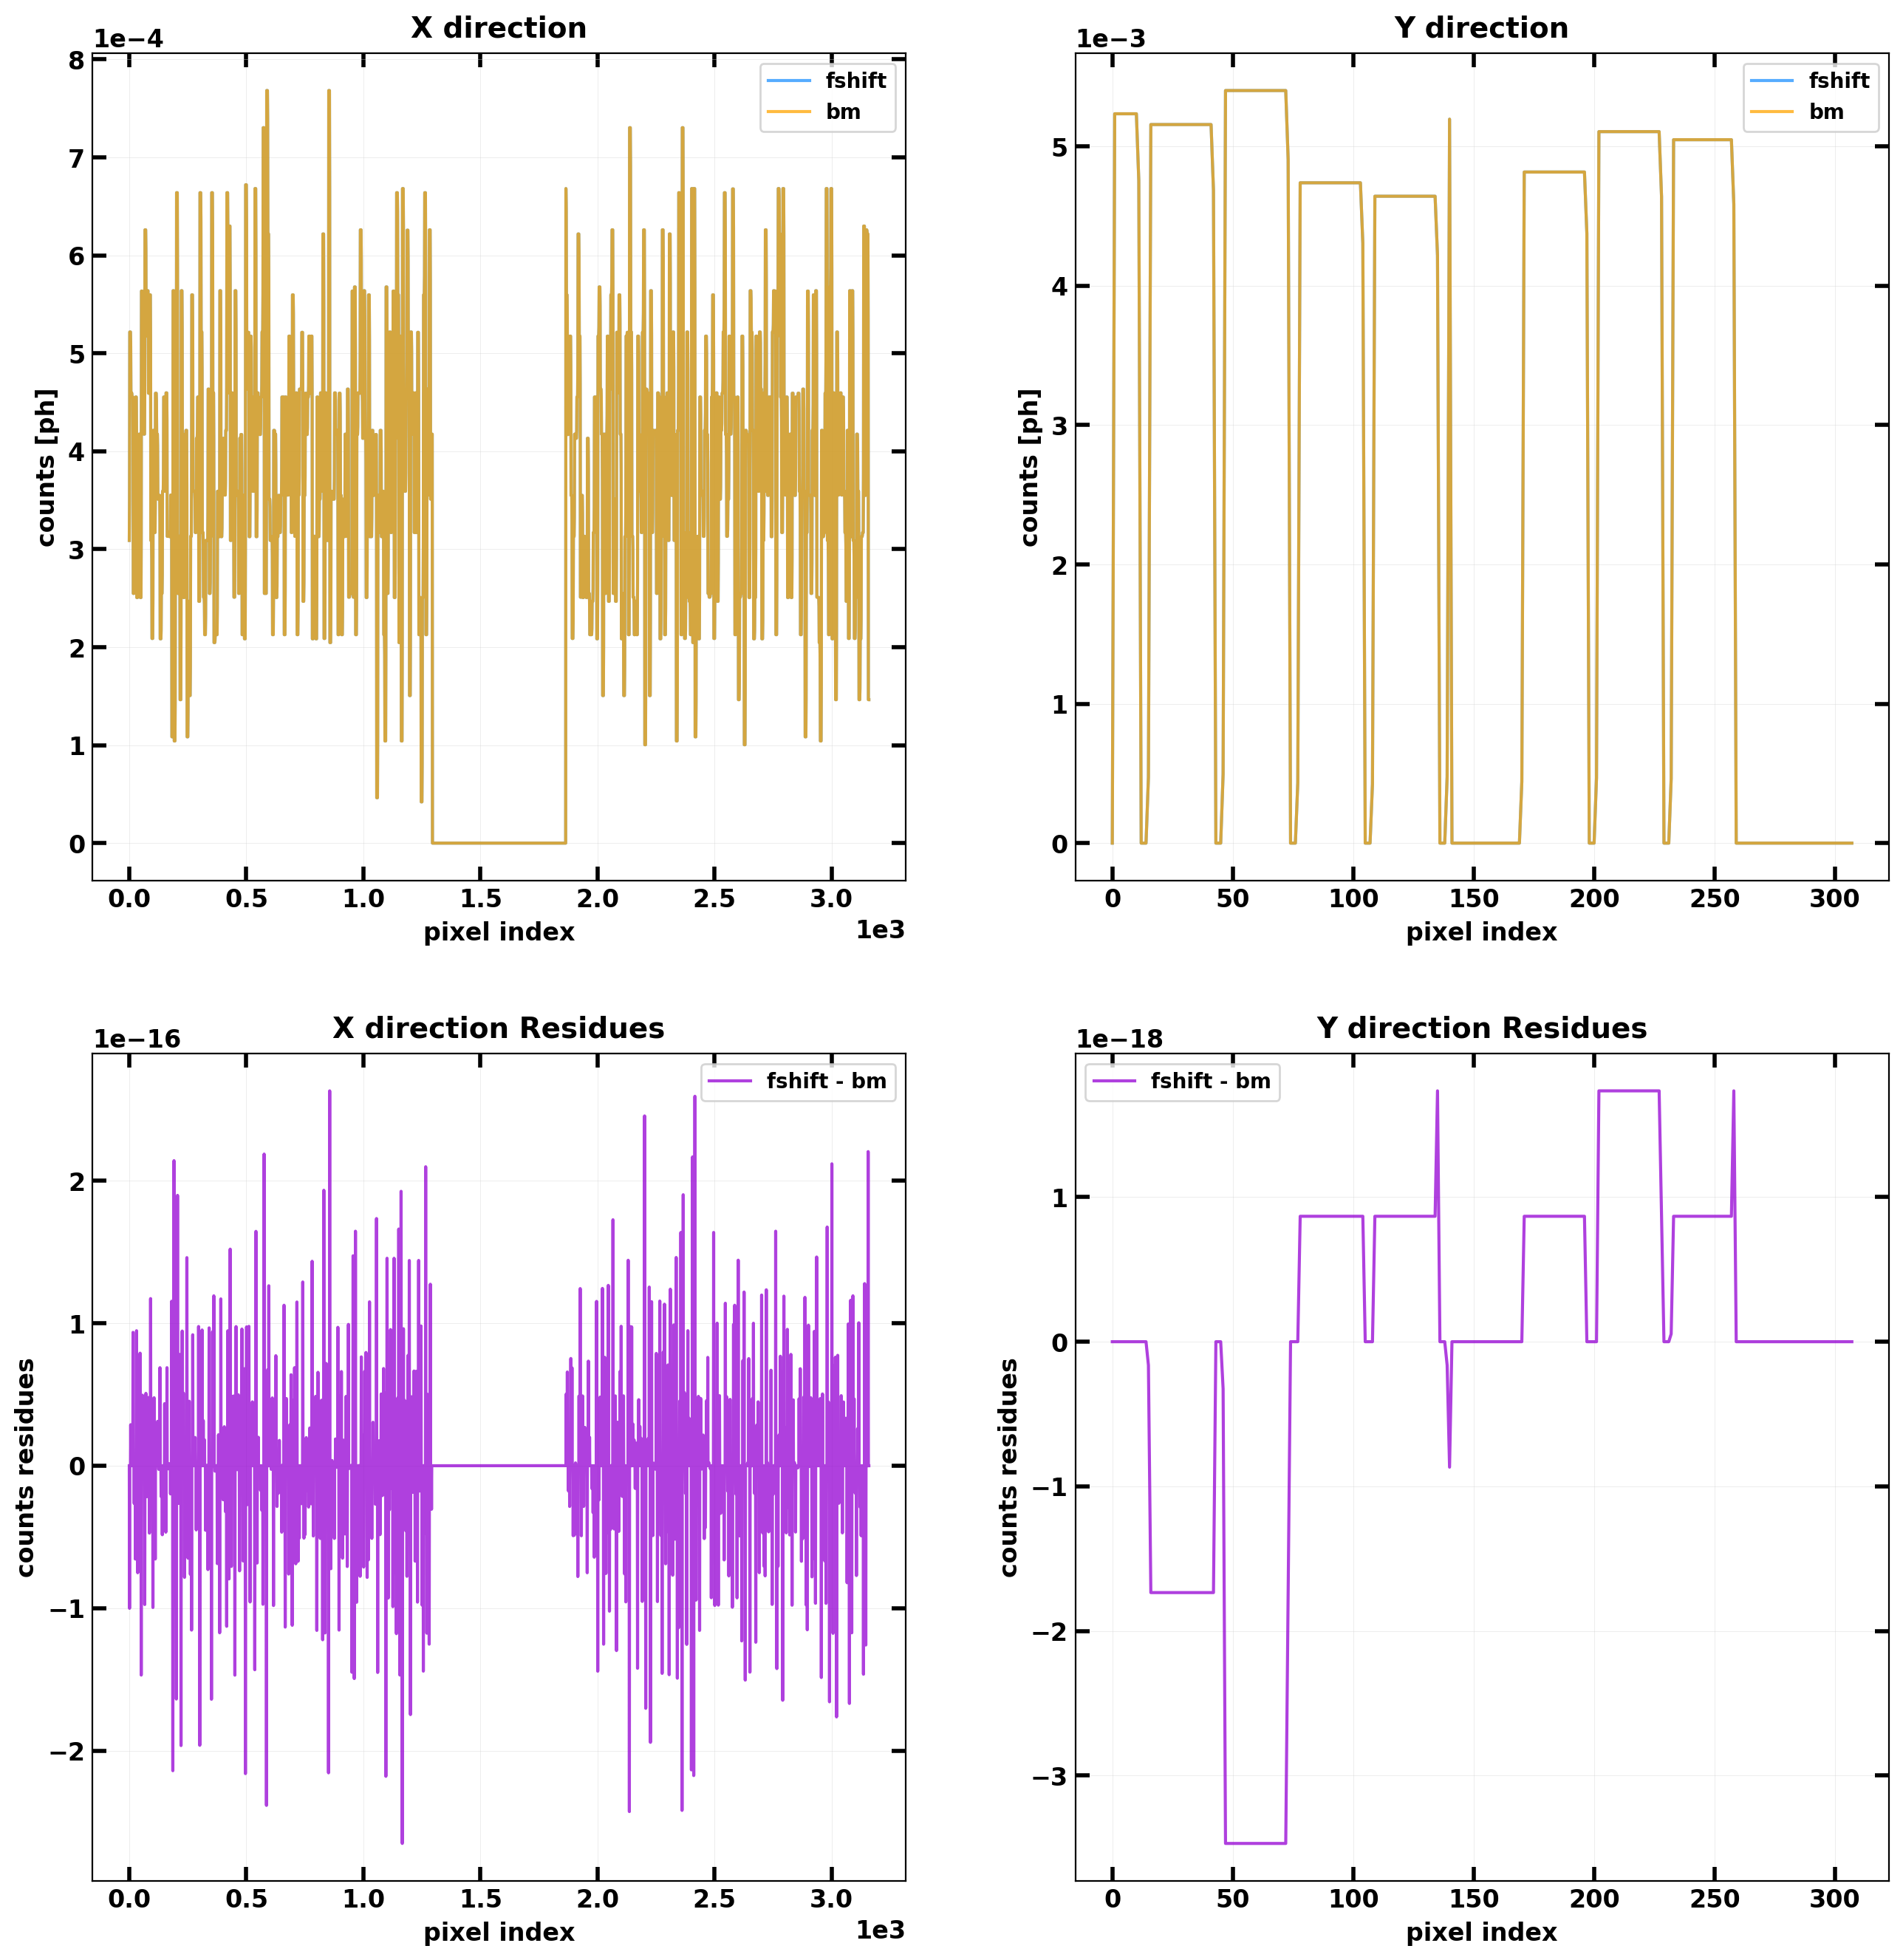

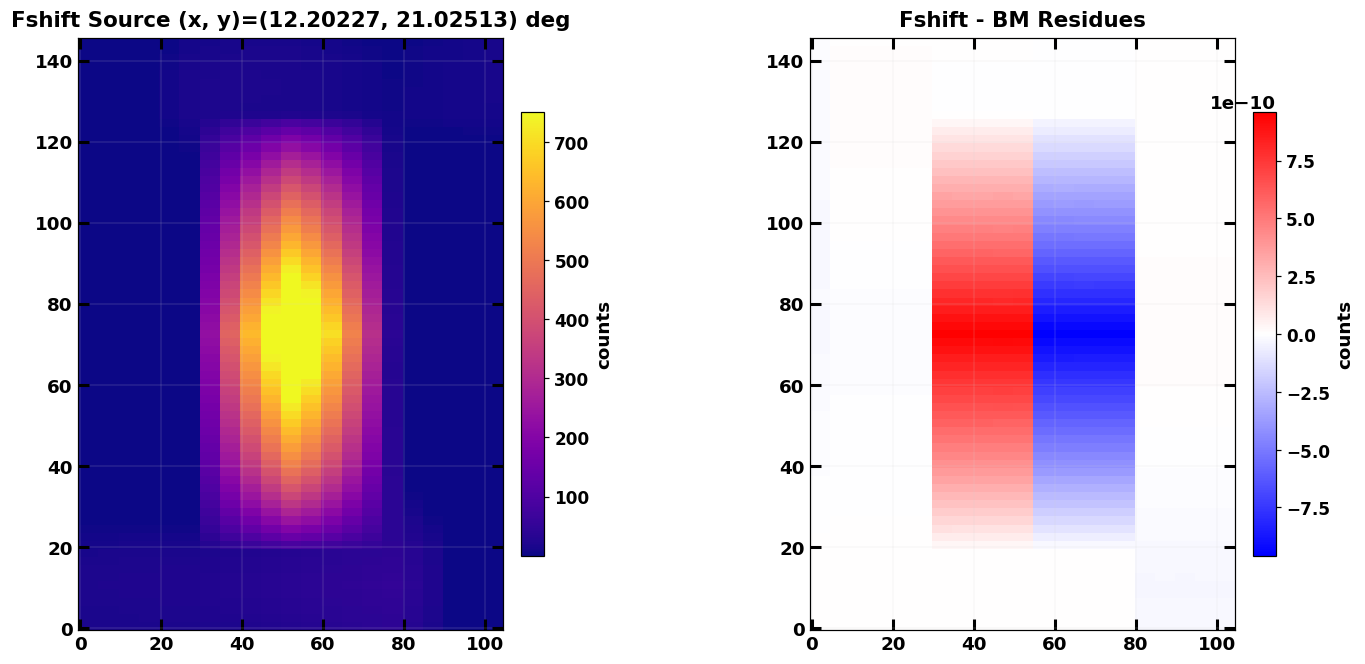

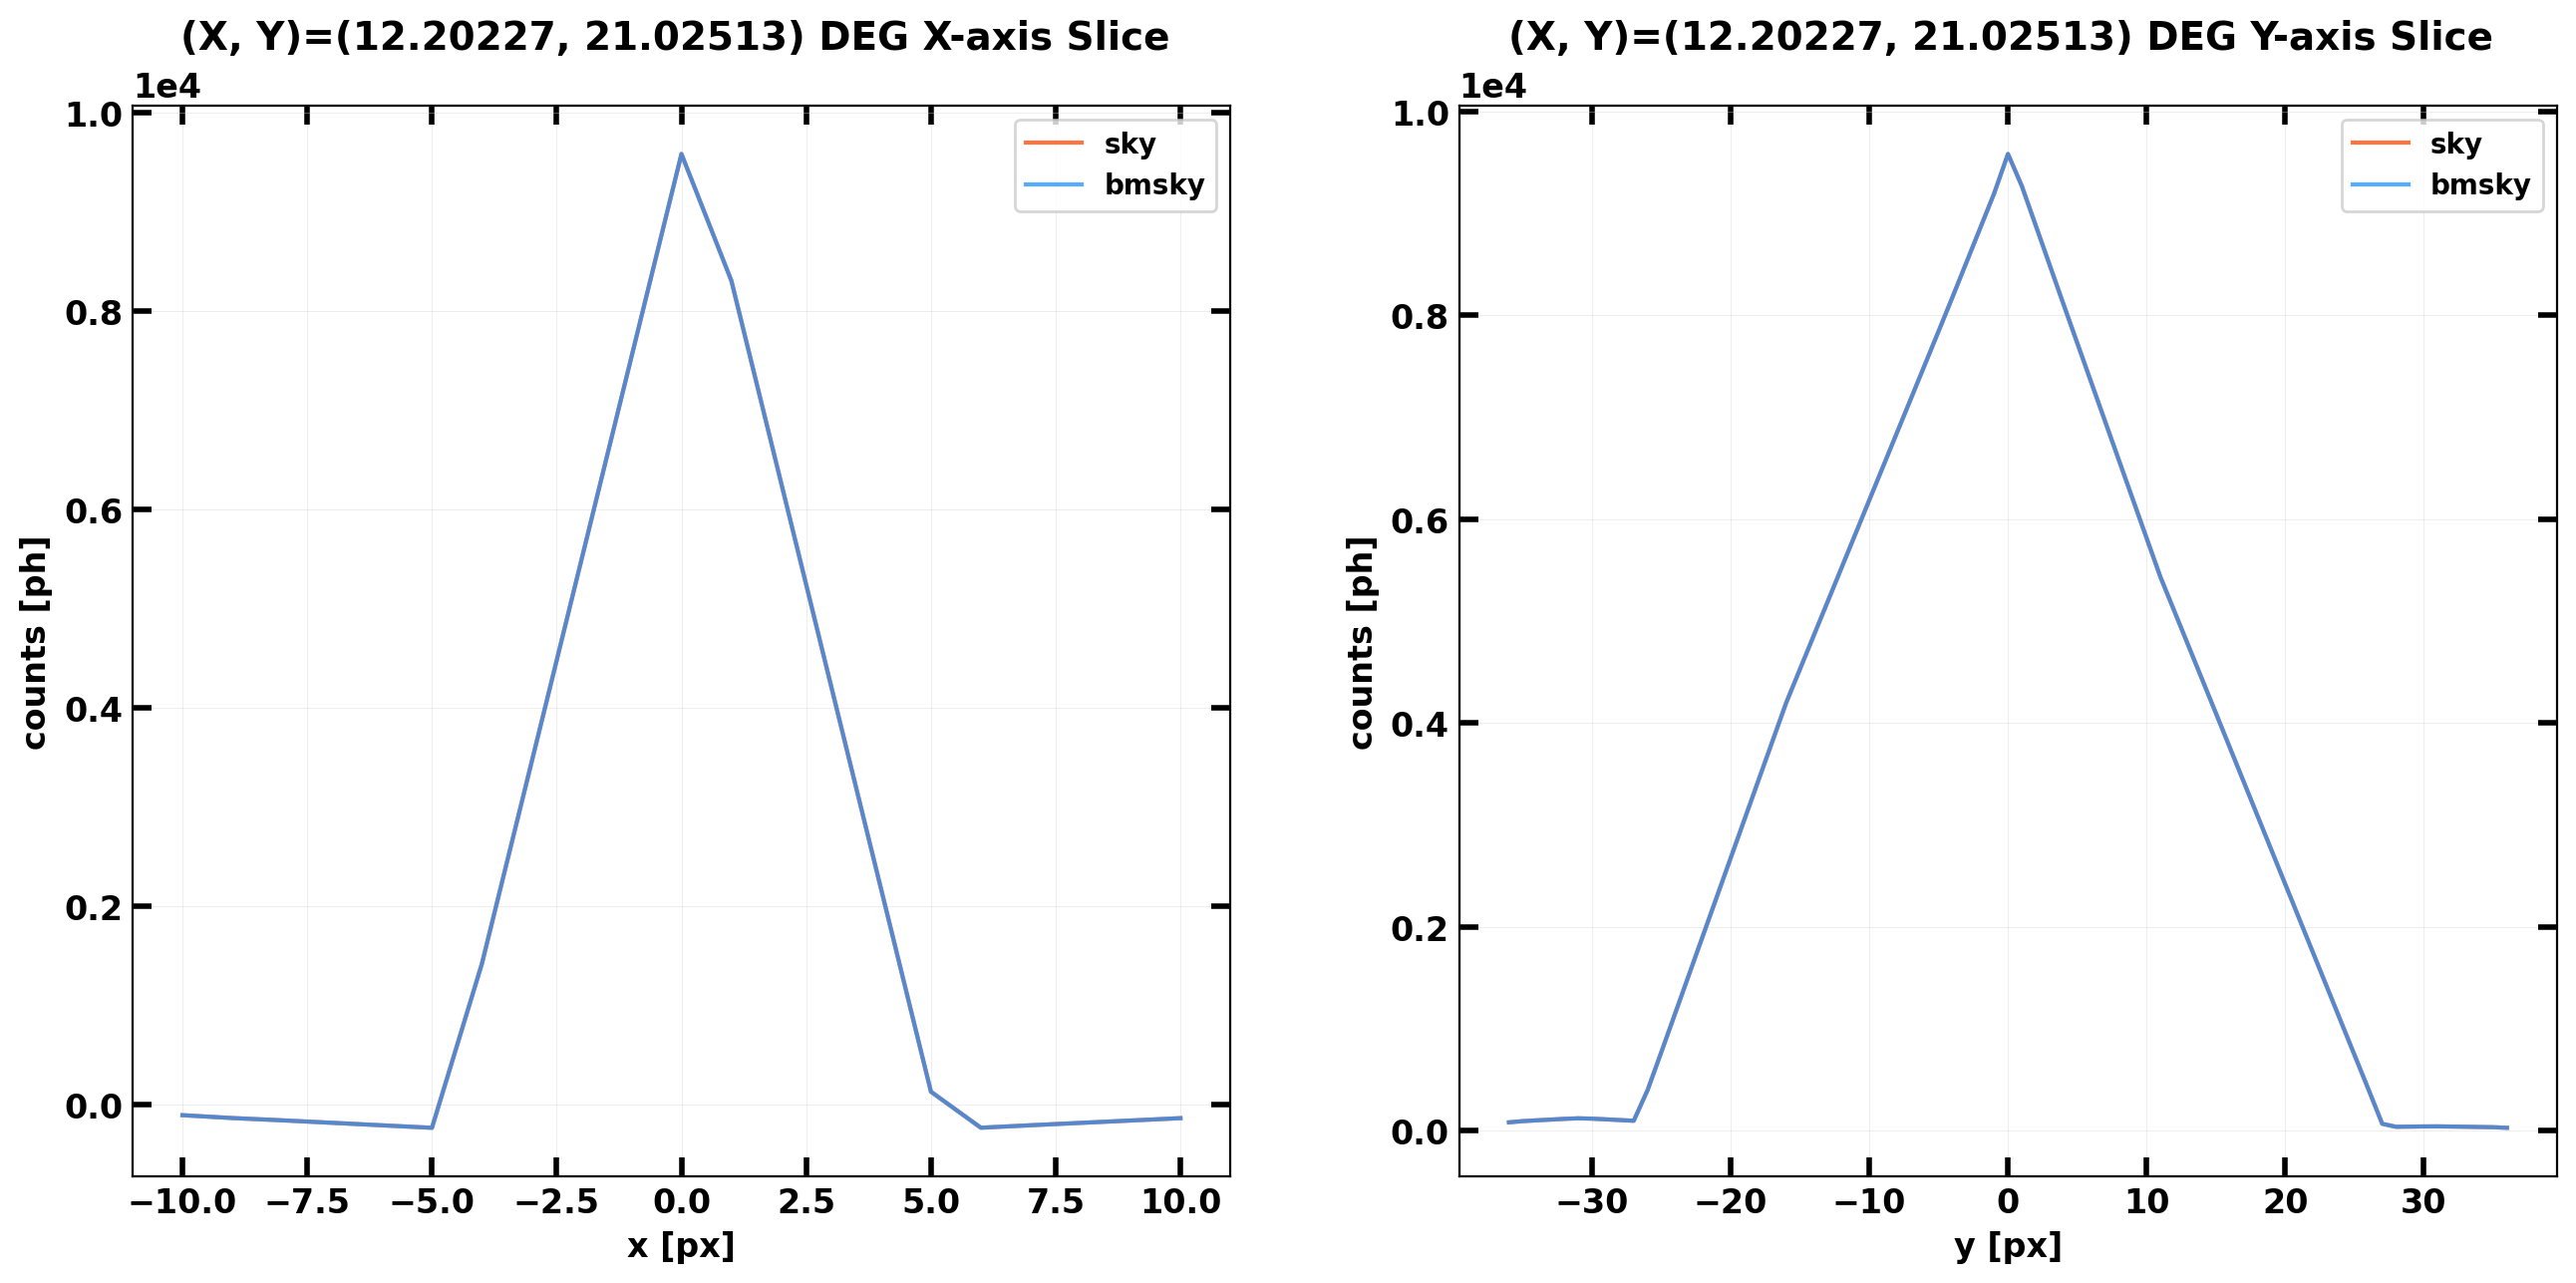

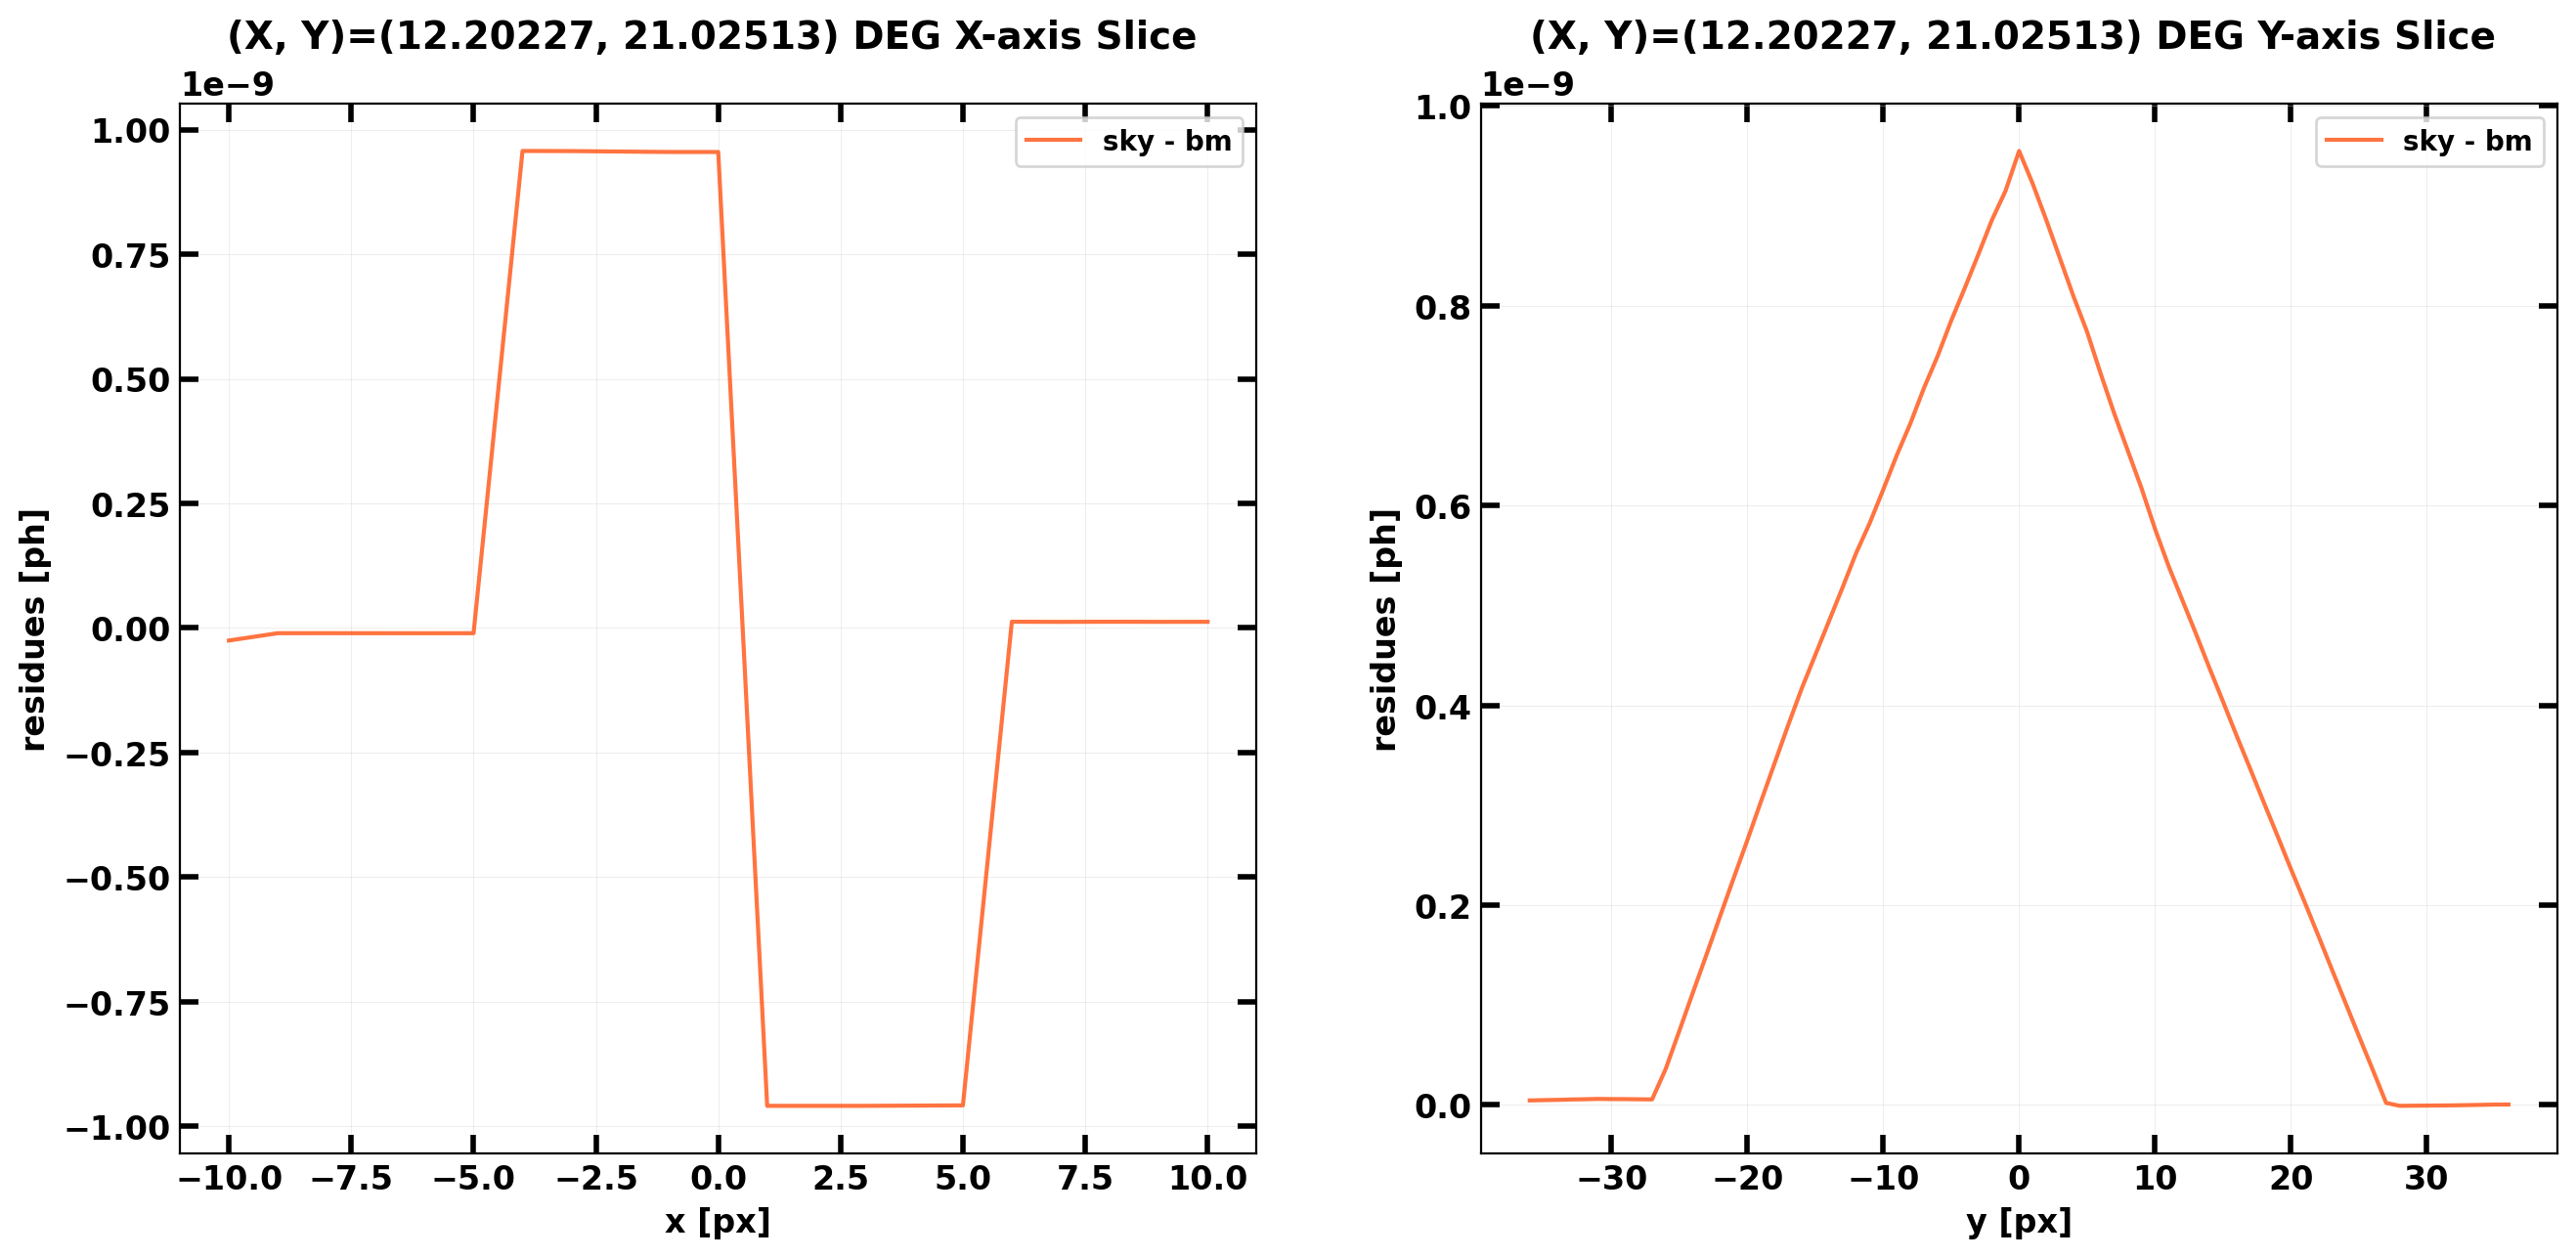

In [3]:
from pathlib import Path

import numpy as np
from numpy.typing import NDArray

from fract_shift2 import model_shadowgram

from bloodmoon.coords import shift2pos, angle2shift
from bloodmoon.mask import codedmask, decode
from bloodmoon.optim import model_shadowgram as bm_shadowgram

import darksun as ds

UPX, UPY = 5, 1
mask_path = '/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/Simulations/wfm_mask_NTHT_20250725.fits'
#mask_path = '/mnt/d/PhD_AASS/Coding/Images_fits/wfm_mask_NTHT_20250725.fits'
wfm = codedmask(mask_path, UPX, UPY)
ASPECT = (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)


thetax, thetay = 12.20227, 21.02513
shiftx, shifty = map(
    lambda x: angle2shift(wfm, x),
    (thetax, thetay),
)

VIGNETTING = False
PSFY = False

detector = model_shadowgram(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
bm_detector = bm_shadowgram(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    vignetting=VIGNETTING,
    psfy=PSFY,
)

def is_img(save_to: str, name: str, frmt: str = 'png') -> str | None:
    """
    Checks if a Figure has been already saved.
    """
    def savefig(figname: str) -> str:
        """Defines dirpath location to save a Figure."""
        return f'{save_to}/{figname}.{frmt}'

    filepath: str = savefig(name)
    if Path(filepath).is_file():
        return None
    return filepath

def sqrt_display(arr: NDArray, exp: int | float) -> NDArray:
    """Computes the root of the input array with the given exponent."""
    if exp > 1:
        raise ValueError('The exponent is supposed to be in the range [0, 1].')
    return np.pow(np.clip(arr, a_min=1e-5, a_max=None), exp)


save_to = '/home/edoardo/Desktop/FSHIFT_test_imgs'
tx_, ty_ = map(int, (thetax, thetay))


resdet = detector - bm_detector
lim = np.max(np.abs(resdet))
ds.image_plot(
    dmaps=(
        ds.map4image(
            img=detector,
            title=f'Fshift Detector (x, y)=({thetax}, {thetay}) deg',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'hot',
                'vmin': np.unique(detector)[1],
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=resdet,
            title='Fshift - BM Residues',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'bwr',
                'vmin': -lim,
                'vmax': lim,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
    #save_to=is_img(save_to, f'detector_{tx_}{ty_}_sameVignettingSign'),
)
# collapse along axes
collapsed_x, collapsed_bmx = map(
    lambda x: np.sum(x, axis=0),
    (detector, bm_detector),
)
collapsed_y, collapsed_bmy = map(
    lambda x: np.sum(x, axis=1),
    (detector, bm_detector),
)
dmapx = ds.map4plot(
    arrs=(collapsed_x, collapsed_bmx),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('fshift', 'bm'),
    color=('DodgerBlue', 'Orange'),
    #ylim=(0, max(collapsed_x.max(), collapsed_bmx.max())),
)
dmapy = ds.map4plot(
    arrs=(collapsed_y, collapsed_bmy),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('fshift', 'bm'),
    color=('DodgerBlue', 'Orange'),
    #ylim=(0, max(collapsed_y.max(), collapsed_bmy.max())),
)
dmapx_res = ds.map4plot(
    arrs=collapsed_x - collapsed_bmx,
    title='X direction Residues',
    ylabel='counts residues',
    xlabel='pixel index',
    labels=('fshift - bm'),
    color=('DarkViolet'),
    #ylim=(-1.5e4, 1.2e4),
)
dmapy_res = ds.map4plot(
    arrs=collapsed_y - collapsed_bmy,
    title='Y direction Residues',
    ylabel='counts residues',
    xlabel='pixel index',
    labels=('fshift - bm'),
    color=('DarkViolet'),
    #ylim=(-1.5e4, 1.2e4),
)
ds.plot(
    dmaps=(dmapx, dmapy, dmapx_res, dmapy_res),
    ncols=2,
    nrows=2,
)


fluence = 1e4
exp = 0.75
sky, bm_sky = map(
    lambda x: fluence * decode(wfm, x),
    (detector, bm_detector),
)
res_sky = sky - bm_sky
lim = np.max(np.abs(res_sky))

i, j = shift2pos(wfm, shiftx, shifty)
crp = (
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
)
crp_sky = ds.crop(
    image=sqrt_display(sky, exp),
    pos=(i, j),
    crp=crp,
)
crp_res_sky = ds.crop(
    image=res_sky,
    pos=(i, j),
    crp=crp,
)
F_UPY, F_UPX = 2, 5

ds.image_plot(
    dmaps=(
        ds.map4image(
            img=ds.upscale(crp_sky, F_UPY, F_UPX) * np.prod((F_UPY, F_UPX)),
            title=f'Fshift Source (x, y)=({thetax}, {thetay}) deg',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'plasma',
                'vmax': 0.75 * pow(fluence, exp),
                #'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=ds.upscale(crp_res_sky, F_UPY, F_UPX) * np.prod((F_UPY, F_UPX)),
            title=f'Fshift - BM Residues',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'bwr',
                'vmin': -lim,
                'vmax': lim,
                #'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
    #save_to=is_img(save_to, f'sky_{tx_}{ty_}_sameVignettingSign'),
)
ds.slices_plot(
    sky=(sky, bm_sky),
    pos=(i, j),
    crp=crp,
    source=f'(x, y)=({thetax}, {thetay}) deg',
    labels=('sky', 'bmsky'),
    #save_to=is_img(save_to, f'skyslice_{tx_}{ty_}_sameVignettingSign'),
)
ds.slices_plot(
    sky=res_sky,
    pos=(i, j),
    crp=crp,
    source=f'(x, y)=({thetax}, {thetay}) deg',
    ylabel='residues [ph]',
    labels='sky - bm',
    #save_to=is_img(save_to, f'skyslice_res_{tx_}{ty_}_sameVignettingSign'),
)

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


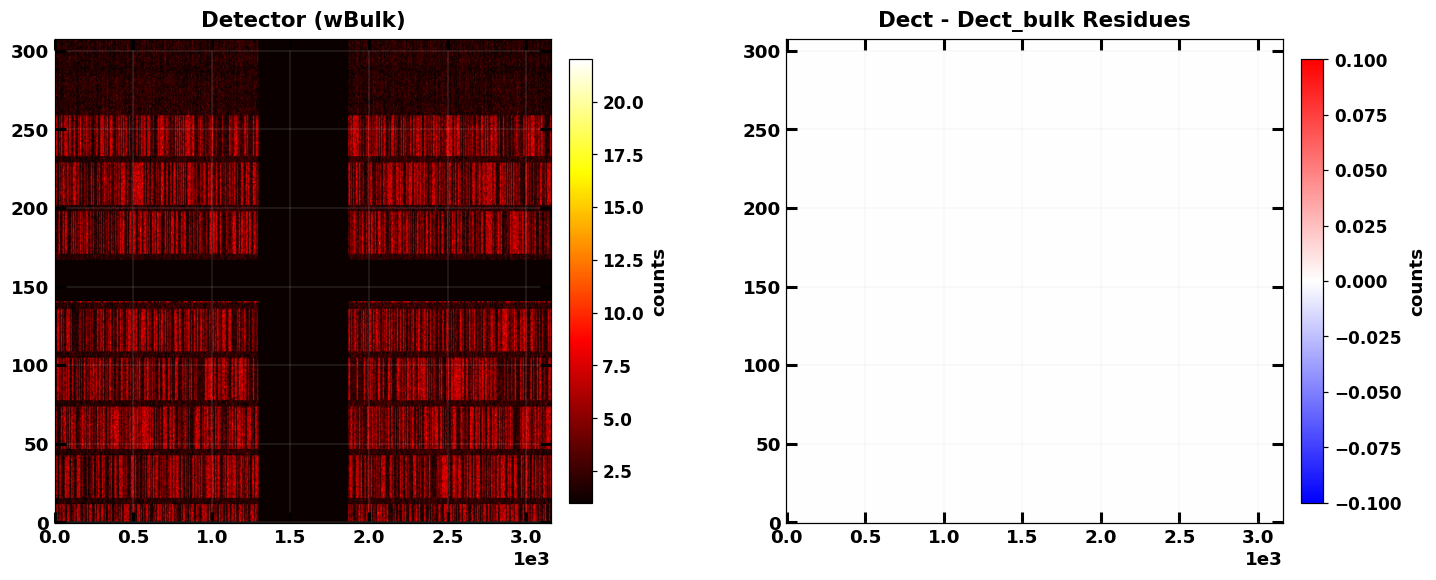

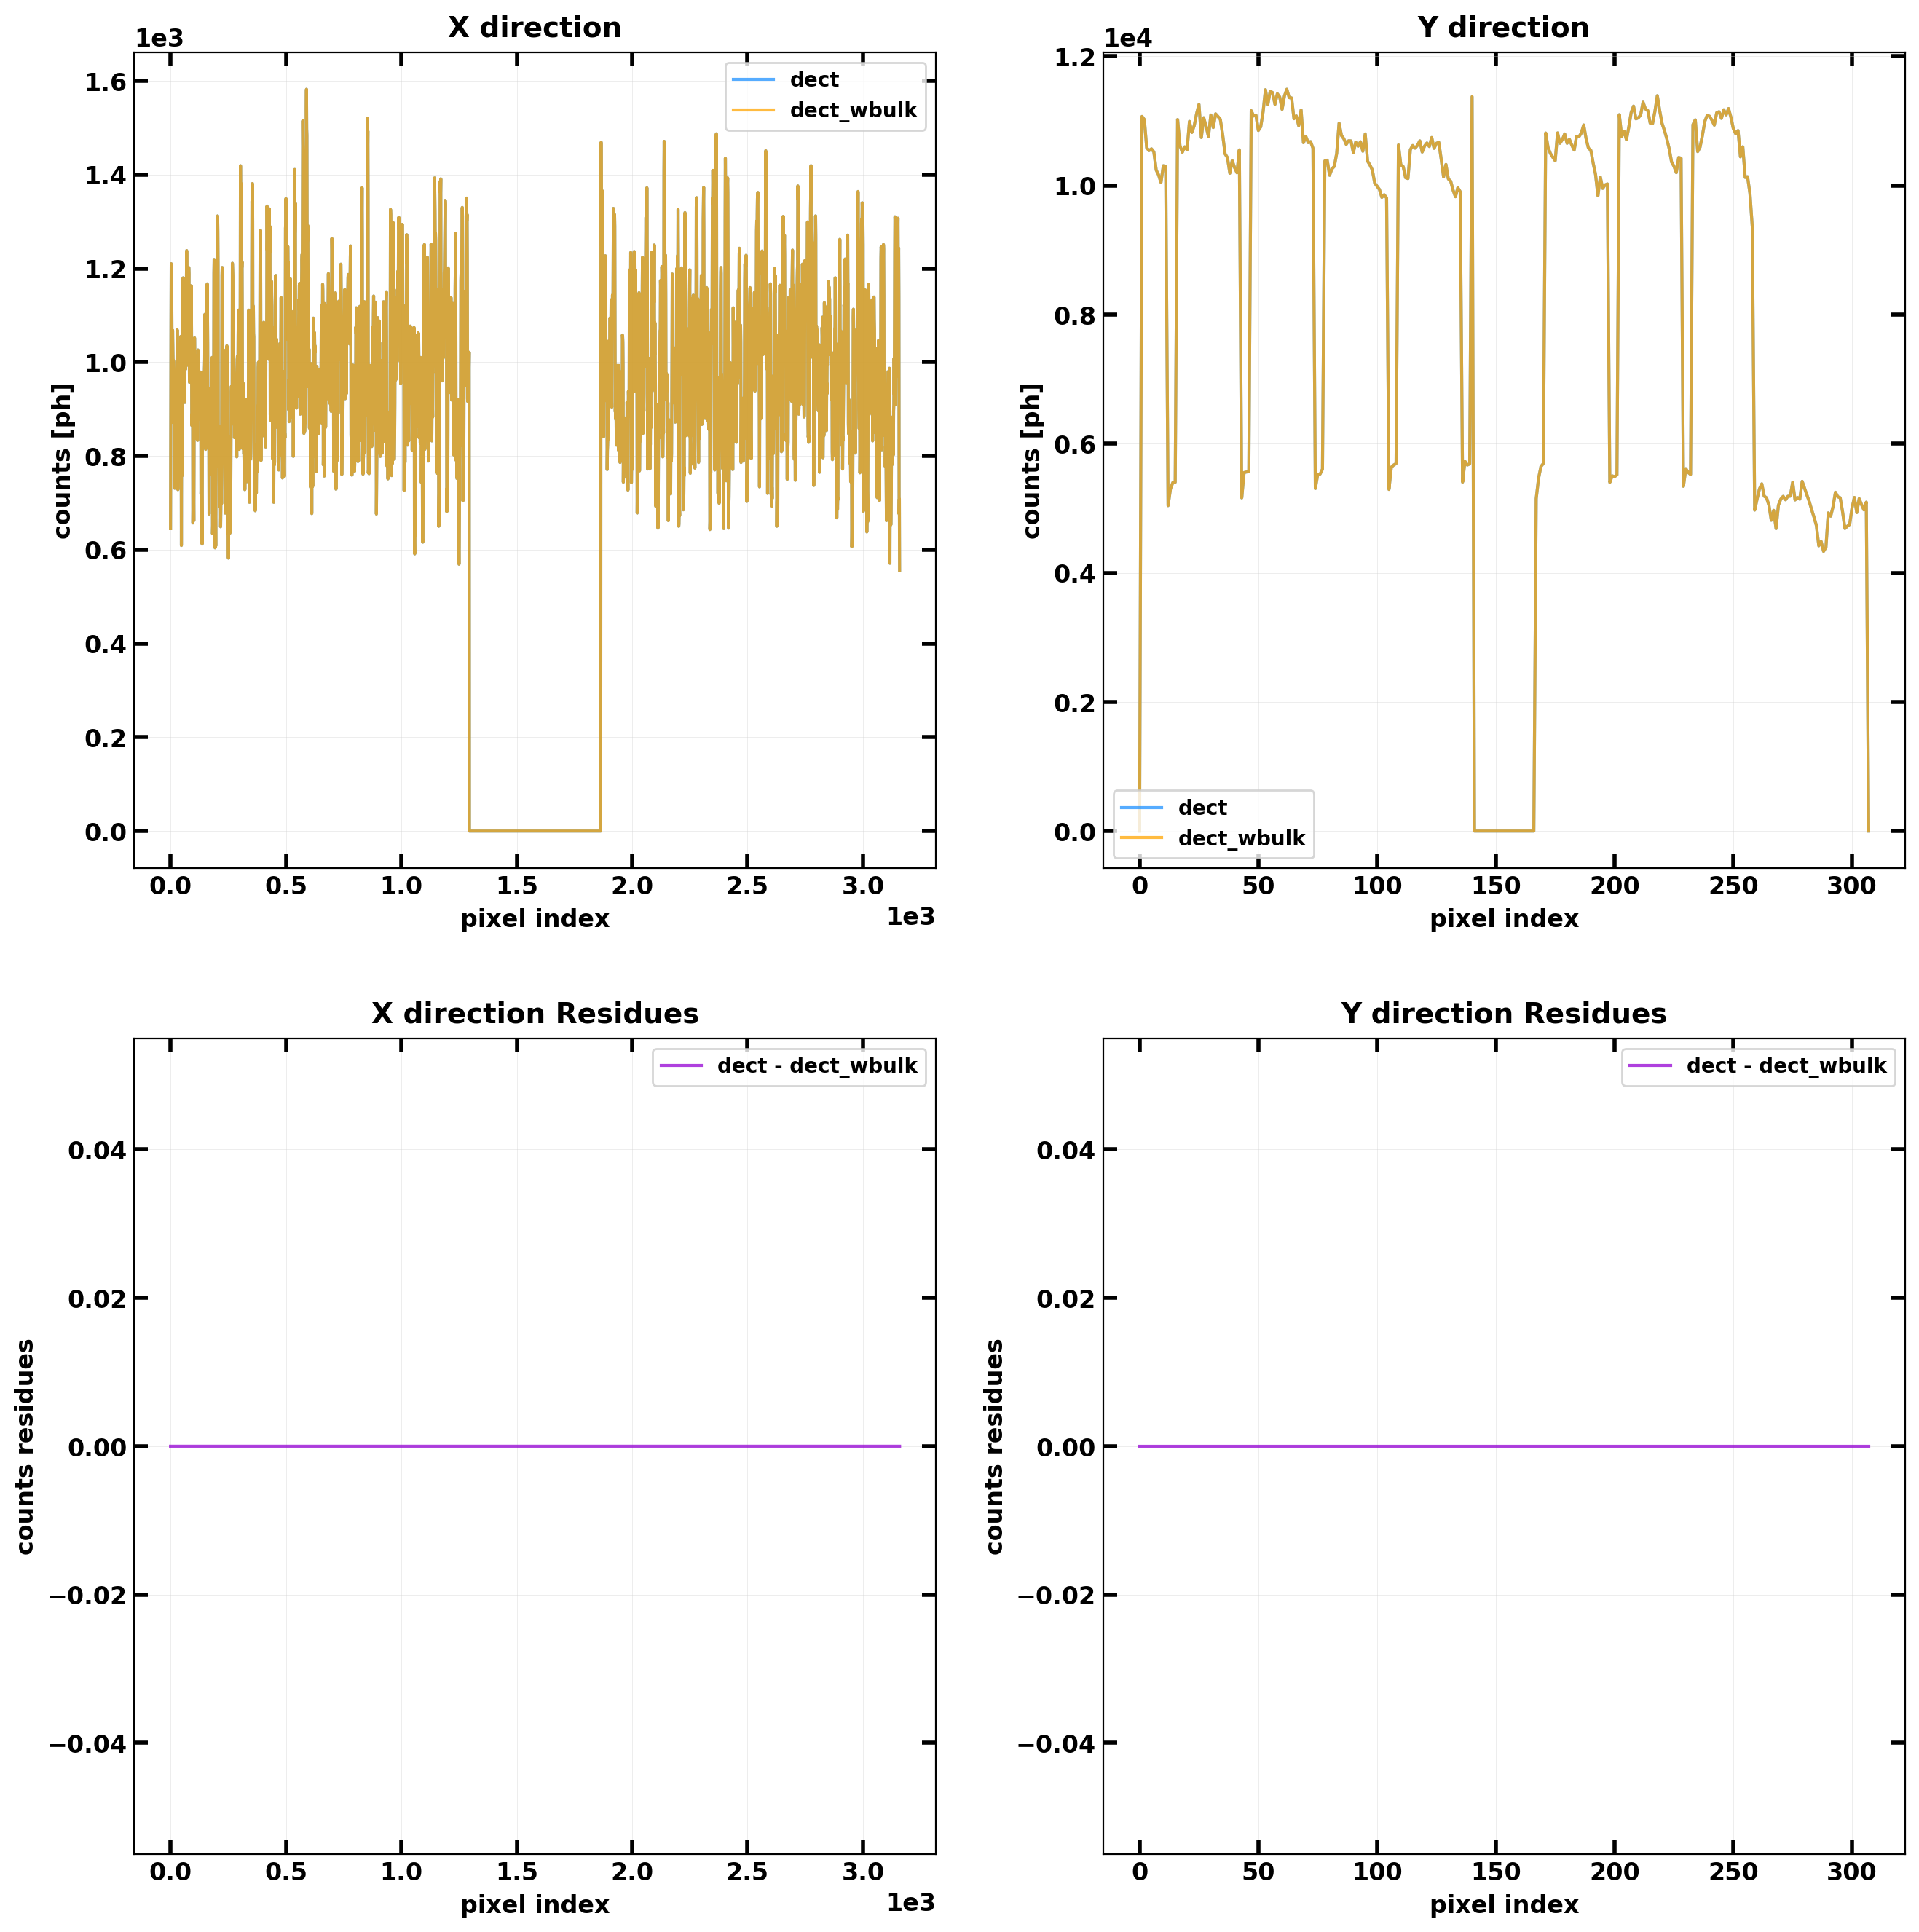

In [ ]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

import numpy as np
import pandas as pd

from bloodmoon.io import simulation_files
from bloodmoon.mask import codedmask, count, decode

import darksun as ds


skyfield = "GalacticCentre"
mask_FITS = "wfm_mask_NTHT_20250725.fits"
data_FITS = "galctr_rxte-sax_2-50keV_mask_050_1040x17_opaquemask_infdet"

N_TEST = "singleCAM_iros_testing_optNoP_modelSG"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = 'detected'

filepaths = simulation_files(simul_data)
sdlA = ds.get_data(filepaths[cam_a][dataset])
# catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])
sdlB = ds.get_data(filepaths[cam_b][dataset])
# catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])

simul_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
simul_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{N_TEST}.fits")


detector_camA, _ = count(wfm, sdlA.DLdata) # removing the * (bulk > 0) in counts
detector_camA_wbulk, _ = count(wfm, sdlA.DLdata);  detector_camA_wbulk *= wfm.bulk
sky_trueA = decode(wfm, detector_camA)
sky_trueA_wbulk = decode(wfm, detector_camA_wbulk)

resdet = detector_camA - detector_camA_wbulk
lim = np.max(np.abs(resdet))
ASPECT = (wfm.specs['mask_deltay'] / UPY) / (wfm.specs['mask_deltax'] / UPX)
ds.image_plot(
    dmaps=(
        ds.map4image(
            img=detector_camA_wbulk,
            title=f'Detector (wBulk)',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'hot',
                'vmin': np.unique(detector_camA_wbulk)[1],
                'aspect': ASPECT,
            },
        ),
        ds.map4image(
            img=resdet,
            title='Dect - Dect_bulk Residues',
            cbarlabel='counts',
            img_kwargs={
                'cmap': 'bwr',
                'vmin': -lim,
                'vmax': lim,
                'aspect': ASPECT,
            },
        ),
    ),
    ncols=2,
    #save_to=is_img(save_to, f'detector_{tx_}{ty_}_sameVignettingSign'),
)
# collapse along axes
collapsed_x, collapsed_bmx = map(
    lambda x: np.sum(x, axis=0),
    (detector_camA, detector_camA_wbulk),
)
collapsed_y, collapsed_bmy = map(
    lambda x: np.sum(x, axis=1),
    (detector_camA, detector_camA_wbulk),
)
dmapx = ds.map4plot(
    arrs=(collapsed_x, collapsed_bmx),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('dect', 'dect_wbulk'),
    color=('DodgerBlue', 'Orange'),
    #ylim=(0, max(collapsed_x.max(), collapsed_bmx.max())),
)
dmapy = ds.map4plot(
    arrs=(collapsed_y, collapsed_bmy),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('dect', 'dect_wbulk'),
    color=('DodgerBlue', 'Orange'),
    #ylim=(0, max(collapsed_y.max(), collapsed_bmy.max())),
)
dmapx_res = ds.map4plot(
    arrs=collapsed_x - collapsed_bmx,
    title='X direction Residues',
    ylabel='counts residues',
    xlabel='pixel index',
    labels=('dect - dect_wbulk'),
    color=('DarkViolet'),
    #ylim=(-1.5e4, 1.2e4),
)
dmapy_res = ds.map4plot(
    arrs=collapsed_y - collapsed_bmy,
    title='Y direction Residues',
    ylabel='counts residues',
    xlabel='pixel index',
    labels=('dect - dect_wbulk'),
    color=('DarkViolet'),
    #ylim=(-1.5e4, 1.2e4),
)
ds.plot(
    dmaps=(dmapx, dmapy, dmapx_res, dmapy_res),
    ncols=2,
    nrows=2,
)